# Latent dynamics of the left hippocampus across four cohorts

**Results notebook for the experiment `LHipp_LatentDynamics_CrossCohort_v1`.** Five dynamics models — a direct
cocycle, a plain neural ODE, BrainODE, and a faithful and a residual Latent ODE — are compared on four frozen shape
representations (PCA-128, SpiralNet-128, Adaptive-128, LAMM-128) over ADNI, AIBL, OASIS-3 and CALSNIC, following
BrainODE's evaluation protocol.

Every number is read from the stored stage 1–5 outputs; this notebook only plots them and runs a few CPU forward
passes for the mesh figures. Absolute errors are not comparable with BrainODE's published numbers (different
template, fitting, PCA and subjects): claims rest on rankings, skill against no-change and disease fidelity inside
this benchmark.

**Contents.** 1 Study design · 2 Key findings and quality gates · 3 Cohorts and meshes · 4 Shape representations ·
5 ADNI benchmark · 6 Cross-cohort transfer · 7 Ablations · 8 Sensitivity analyses · 9 Converter line ·
10 Context and limitations · 11 Reproducibility

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.colors import Normalize, TwoSlopeNorm

import lhipp_results as R

plt = R.style()
INK, SLOTS = R.INK, R.SLOTS
SHOWN = [m for m in R.METHODS if m != "latent_ode"]  # the faithful Latent ODE is off-scale in several charts; it stays in every table
display(Markdown(R.provenance_markdown()))

**Results root:** `/mnt/bulk10tb/Deep3DComp/LHipp_LatentDynamics_CrossCohort_v1`  
**Consolidated report:** `/mnt/bulk10tb/Deep3DComp/LHipp_LatentDynamics_CrossCohort_v1/stage5_brainode_style/reports/brainode_style_report.md` (sha256 `f0c4568ba5c0dbed…`, rebuilt byte-identically: yes, 26 files)  
**Missing evaluations:** 0

## 1. Study design

| component | setting |
|---|---|
| Structure | left hippocampus; SynthSeg segmentation; template correspondence meshes (2,746 vertices, 5,488 faces) |
| Cohorts | ADNI (CN and AD, no MCI), AIBL, OASIS-3, CALSNIC (ALS as an out-of-distribution disease) |
| Representations | PCA-128 (first 128 components of an ADNI-train PCA-150), SpiralNet-128, Adaptive-128, LAMM-128 — all fitted on ADNI train only and frozen |
| Dynamics | **Cocycle** Φ(z,s,t,d) = z + (t−s)[v_CN + d·v_AD]; **plain ODE** and **BrainODE** (RK4 on a residual MLP / singleton-attention field); **Latent ODE** (ODE-RNN encoder; faithful decoder of the full code, or residual decoder of the change) |
| Condition d | subject diagnosis: 0 control, 1 disease |
| Tasks (target = latest visit) | one-shot from the first visit; one-shot from the previous visit; all prior visits (k ≤ 4); BrainODE 4-shot (≥ 5 visits) |
| Metric | per-vertex Euclidean distance (mm) to the real latest mesh; skill = 1 − error / no-change error on the same subjects |
| Disease fidelity | AD capture = predicted / observed annual log-volume change of AD subjects |
| Statistics | subject bootstrap 95% CIs (2,000 draws); paired differences vs the cocycle; Wilcoxon + Holm; seeds 42–44 |

| protocol | trained on | tested on |
|---|---|---|
| P0 internal | ADNI train | ADNI test |
| P1 zero-shot | ADNI train (P0 checkpoints) | AIBL, OASIS-3, CALSNIC: test split and whole cohort |
| P2 internal | the cohort's own train split (plus 5-fold cross-fit) | its test split / out-of-fold |
| P3 pooled | ADNI + AIBL + OASIS-3 train | each cohort's test split and the unified test |
| P4 leave-one-cohort-out | two of ADNI, AIBL, OASIS-3 | the held-out cohort |
| P4b / P4c | AIBL / pooled | ADNI + OASIS-3 / CALSNIC |
| P5 converter line | pooled + inclusive AIBL/OASIS-3 converters | converter test split |

**Pre-registered endpoints.** E1 ADNI one-shot error; E2 ADNI AD capture; E3 pooled-protocol AIBL all-prior error;
E4 AIBL zero-shot one-shot error. A model is preferred over the cocycle only if it brings E2 closer to 100% (CI
excluding 0) and is non-inferior on E1 (upper CI of the paired difference ≤ 2% of the no-change error); otherwise
models rank by E1.

## 2. Key findings and quality gates

In [2]:
display(Markdown(R.key_findings_markdown()))

- **ADNI one-shot error (range over the four representations):** Cocycle (direct C4) 0.312–0.316 mm; Plain ODE 0.316–0.326 mm; BrainODE 0.319–0.328 mm; Latent ODE (faithful) 0.413–0.556 mm; Latent ODE (residual) 0.310–0.314 mm; no-change 0.344 mm.
- **Pre-registered decision (E1 non-inferiority + E2 closer to 100%):** no method is preferred over the cocycle in any representation. Lowest E1 per representation — PCA-128: Latent ODE (residual); SpiralNet-128: Latent ODE (residual); Adaptive-128: Cocycle (direct C4); LAMM-128: Latent ODE (residual).
- **AD atrophy captured on ADNI (predicted / observed AD rate):** Cocycle (direct C4) 0.81–0.84; Plain ODE 0.30–0.54; BrainODE 0.27–0.52; Latent ODE (faithful) 0.74–0.98; Latent ODE (residual) 0.72–0.91.
- **Zero-shot skill on whole external cohorts (mean over representations):** AIBL: Cocycle (direct C4) +5.1%, Latent ODE (residual) +6.3%, Plain ODE +4.4%, BrainODE +3.5%; OASIS-3: Cocycle (direct C4) +4.1%, Latent ODE (residual) +3.4%, Plain ODE +2.9%, BrainODE -0.1%; CALSNIC: Cocycle (direct C4) +0.3%, Latent ODE (residual) +1.1%, Plain ODE +0.2%, BrainODE +0.2%.
- **Ablations (PCA, ADNI):** AD capture cocycle 0.83, without disease head 0.65; BrainODE 0.27, BrainODE field + cocycle loss 0.68; exact coboundary 0.17 (PCA) / 0.21 (SpiralNet).
- **Converter line (5 test AD converters, descriptive):** AD-converter one-shot error C0 0.571 mm, C1 prefix-only 0.560 mm, C1 oracle window 0.547 mm (PCA); gate G5.7 (stable non-inferiority) fails for the fine-tuned C1 variants (C1-frozen passes).
- **Pooled PCA basis (sensitivity):** largest paired change -0.0321 mm; the ranking of dynamics is unchanged.

In [3]:
display(R.show(R.gates_table(), "Table 1. Quality gates across stages"))

stage,gate,check,result
1 data foundation,G1.1,topology and faces identical to ADNI,PASS
1 data foundation,G1.2,ADNI codes copied exactly; re-encoding reproduces them,PASS
1 data foundation,G1.3,reconstruction matches published ADNI val and CrossCohort PCA external,PASS
1 data foundation,G1.4,"split, fold, LOCO and standardization hygiene",PASS
1 data foundation,G1.5,evaluable task counts reproduce PLAN section 0.3,PASS
1 data foundation,G1.6,ADNI test no-change reproduces August/task3 anchor summaries,PASS
1 data foundation,G1.7,inclusive converter cohorts built and validated,PASS
1 data foundation,G1.8,stage 1 unit and regression tests,PASS
3 ADNI benchmark,G3.1,all 60 seed-runs complete with val and test evaluations,PASS
3 ADNI benchmark,G3.2,no run loaded test data during training or selection,PASS


**Reading the gates.** G5.6 passes only because onset recovery is as good as the conversion window alone
(section 9). G5.7 fails for the fine-tuned converter cocycle: its stable-subject error exceeds the pooled cocycle's
by more than the 1% margin, so only the frozen variant is admissible under the pre-registered rule.

## 3. Cohorts and meshes

In [4]:
composition = R.table_csv("stage5", "r_t5_composition").rename(columns={
    "age_first_visit": "age at first visit (y)", "observations": "visits per subject", "interval_years": "years between visits"})
display(R.show(composition, "Table 2. Cohort composition (strict cohorts; converter-line subjects listed separately)"))
evaluable = R.table_csv("stage5", "r_t6_evaluable").rename(columns={
    "set": "test set", "one_shot_first": "one-shot (first visit)", "one_shot_prev": "one-shot (previous visit)",
    "four_shot": "4-shot", "all_prior_k": "all prior (k ≤ 4)"})
display(R.show(evaluable, "Table 3. Evaluable test subjects per task", precision=0))

cohort,subjects,control,disease,scans,age at first visit (y),visits per subject,years between visits
ADNI,597,326,271 AD,"2,583",74.7 ± 6.7,4.33 ± 1.90,0.82 ± 0.47
AIBL,148,128,20 AD,482,71.7 ± 7.1,3.26 ± 0.81,1.57 ± 0.32
OASIS,385,379,6 AD,"1,064",67.1 ± 9.6,2.76 ± 0.99,2.92 ± 1.71
CALSNIC,302,158,144 ALS,804,57.5 ± 10.2,2.66 ± 0.47,0.41 ± 0.17
AIBL+OASIS inclusive (converter line),634,518,"28 AD-stable, 12 CN->AD, 26 MCI->AD, 50 CN->MCI","1,846",-,-,-


test set,one-shot (first visit),one-shot (previous visit),4-shot,all prior (k ≤ 4)
P0 ADNI test,61,61,21,58
P1 AIBL whole cohort,148,148,0,114
P1 OASIS whole cohort,385,385,25,184
P1 CALSNIC whole cohort,302,302,0,200
P3 unified test,115,115,26,89
P5 converter test,126,126,27,95


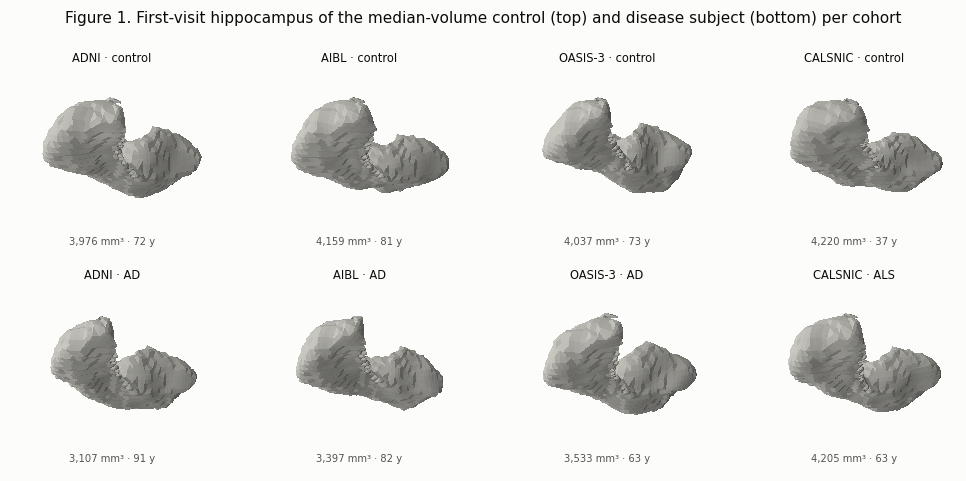

In [5]:
panels = R.cohort_example_panels()
fig = R.render_meshes(panels[0::2] + panels[1::2], ncols=4,
                      title="Figure 1. First-visit hippocampus of the median-volume control (top) and disease subject (bottom) per cohort")
plt.show()

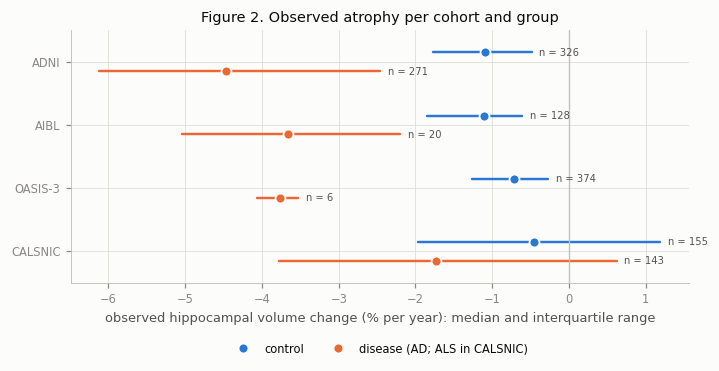

In [6]:
rates = R.observed_rates()
fig, ax = plt.subplots(figsize=(6.6, 3.5))
for offset, (label, name, color) in enumerate(((0, "control", SLOTS[0]), (1, "disease (AD; ALS in CALSNIC)", SLOTS[1]))):
    part = rates[rates.label == label].set_index("cohort").reindex(R.COHORTS)
    for y, (cohort, row) in enumerate(part.iterrows()):
        position = y + (offset - 0.5) * 0.3
        R.interval(ax, position, row["median"], row.q25, row.q75, color, label=name if y == 0 else None)
        ax.annotate(f"n = {int(row.subjects)}", (row.q75, position), xytext=(5, 0), textcoords="offset points", va="center",
                    fontsize=6.5, color=INK["secondary"])
ax.axvline(0, color=INK["baseline"], linewidth=0.9)
ax.set_yticks(range(len(R.COHORTS)), [R.COHORT_LABEL[c] for c in R.COHORTS])
ax.set_ylim(len(R.COHORTS) - 0.5, -0.5)
ax.set_xlabel("observed hippocampal volume change (% per year): median and interquartile range")
ax.set_title("Figure 2. Observed atrophy per cohort and group")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2)
fig.tight_layout()
plt.show()

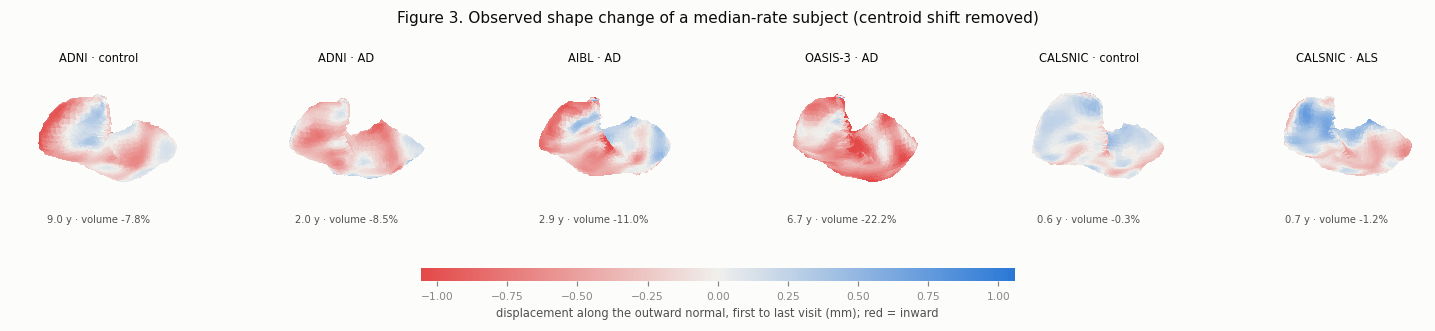

In [7]:
panels, vmax = R.observed_change_panels()
fig = R.render_meshes(panels, ncols=6, cmap=R.diverging_cmap(), norm=TwoSlopeNorm(0.0, -vmax, vmax),
                      colorbar_label="displacement along the outward normal, first to last visit (mm); red = inward",
                      title="Figure 3. Observed shape change of a median-rate subject (centroid shift removed)")
plt.show()

## 4. Shape representations

All four representations are fitted on ADNI train only and frozen; AIBL, OASIS-3 and CALSNIC are encoded with the
ADNI models. The pooled and own-cohort PCA bases are diagnostics: they show how much of the external reconstruction
error comes from the basis rather than from the meshes themselves.

In [8]:
recon = R.reconstruction_table()
display(R.show(recon, "Table 4. Test-split reconstruction coordinate RMSE (mm)", precision=4))

cohort,PCA-128,SpiralNet-128,Adaptive-128,LAMM-128,PCA-128 pooled basis,PCA-128 own-cohort basis
ADNI,0.0344,0.0381,0.0375,0.0346,0.0362,0.0344
AIBL,0.0800,0.0907,0.0887,0.0813,0.0699,0.0883
OASIS-3,0.0849,0.0987,0.0956,0.0870,0.0751,0.0801
CALSNIC,0.0810,0.0941,0.0910,0.0821,0.0710,0.0771


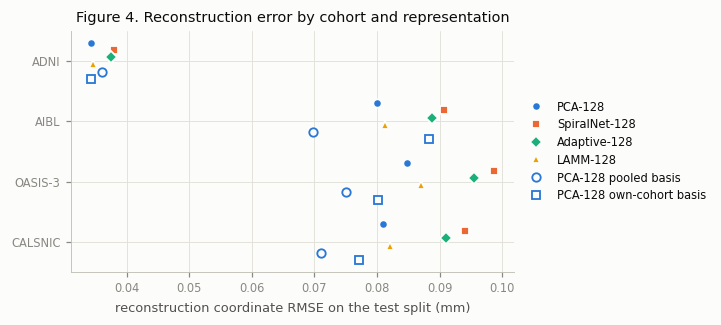

In [9]:
fig, ax = plt.subplots(figsize=(6.6, 3.0))
series = [(R.REP_LABEL[r], R.REP_COLOR[r], R.REP_MARKER[r], True) for r in R.REPS]
series += [("PCA-128 pooled basis", SLOTS[0], "o", False), ("PCA-128 own-cohort basis", SLOTS[0], "s", False)]
for j, (column, color, marker, filled) in enumerate(series):
    for i, value in enumerate(recon[column]):
        R.dot(ax, value, i + (j - 2.5) * 0.12, color, marker=marker, filled=filled, label=column if i == 0 else None, size=5.5)
ax.set_yticks(range(len(recon)), recon.cohort)
ax.set_ylim(len(recon) - 0.5, -0.5)
ax.set_xlabel("reconstruction coordinate RMSE on the test split (mm)")
ax.set_title("Figure 4. Reconstruction error by cohort and representation")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
fig.tight_layout()
plt.show()

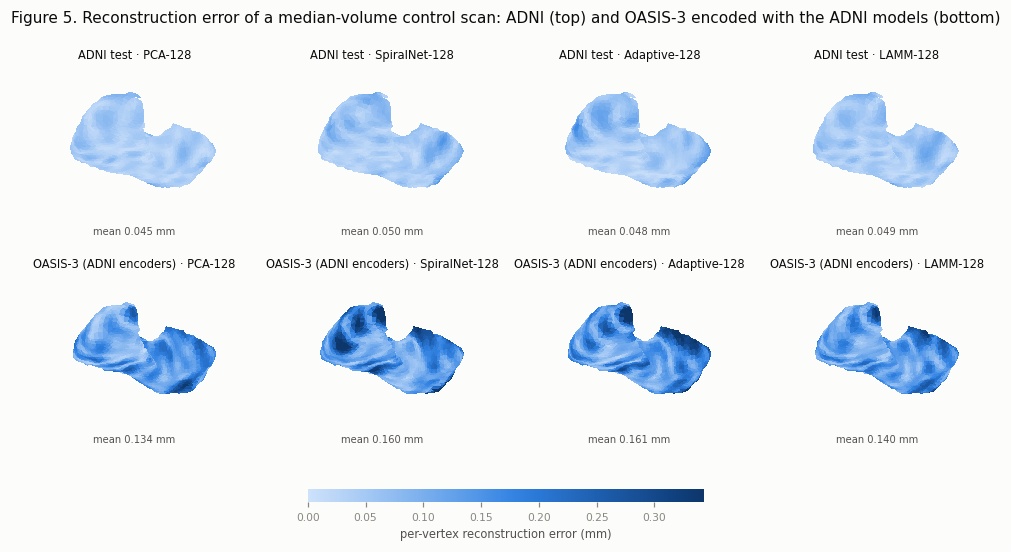

In [10]:
panels, vmax = R.reconstruction_error_panels()
fig = R.render_meshes(panels, ncols=4, cmap=R.sequential_cmap(), norm=Normalize(0.0, vmax),
                      colorbar_label="per-vertex reconstruction error (mm)",
                      title="Figure 5. Reconstruction error of a median-volume control scan: ADNI (top) and OASIS-3 encoded with the ADNI models (bottom)")
plt.show()

## 5. ADNI benchmark (protocol P0: ADNI train → ADNI test, 61 subjects, seeds 42–44)

In [11]:
errors = R.table_csv("stage3", "p3a_errors")
names = {**{m: R.METHOD_LABEL[m] for m in R.METHODS}, "latent_ode__native": "Latent ODE (faithful), native k-shot",
         "latent_ode_residual__native": "Latent ODE (residual), native k-shot",
         "baseline:nochange_decoded": "No-change (decoded)", "baseline:linear_decoded": "Linear extrapolation (decoded)"}
part = errors[errors.model.isin(list(names))].assign(model=lambda f: f.model.map(names))
for task, caption in (("one_shot_first", "Table 5a. One-shot error from the first visit (mm)"),
                      ("all_prior_k", "Table 5b. Error using all prior visits, k ≤ 4 (mm)"),
                      ("four_shot", "Table 5c. BrainODE 4-shot error (21 subjects with ≥ 5 visits, all CN; mm)")):
    cell = part[part.task == task]
    wide = cell.pivot_table(index="model", columns="representation", values="euclidean_mm_mean")
    wide = wide.reindex([n for n in names.values() if n in wide.index])[list(R.REPS)].rename(columns=R.REP_LABEL)
    display(R.show(wide.reset_index(), caption, precision=4))

model,PCA-128,SpiralNet-128,Adaptive-128,LAMM-128
Cocycle (direct C4),0.3134,0.3135,0.3117,0.3155
Plain ODE,0.3258,0.3186,0.3160,0.3171
BrainODE,0.3285,0.3223,0.3191,0.3188
Latent ODE (faithful),0.5556,0.4249,0.4128,0.4199
Latent ODE (residual),0.3130,0.3098,0.3137,0.3098
"Latent ODE (faithful), native k-shot",0.5556,0.4249,0.4128,0.4199
"Latent ODE (residual), native k-shot",0.3130,0.3098,0.3137,0.3098
No-change (decoded),0.3448,0.3439,0.3446,0.3441


model,PCA-128,SpiralNet-128,Adaptive-128,LAMM-128
Cocycle (direct C4),0.2594,0.2618,0.2606,0.2611
Plain ODE,0.2661,0.2645,0.2629,0.2626
BrainODE,0.2657,0.2649,0.2640,0.2630
Latent ODE (faithful),0.5323,0.4080,0.3971,0.3984
Latent ODE (residual),0.2627,0.2623,0.2635,0.2641
"Latent ODE (faithful), native k-shot",0.5357,0.4105,0.4019,0.4049
"Latent ODE (residual), native k-shot",0.2991,0.2974,0.2985,0.2943
No-change (decoded),0.3041,0.3039,0.3041,0.3035
Linear extrapolation (decoded),0.4695,0.4671,0.4661,0.4615


model,PCA-128,SpiralNet-128,Adaptive-128,LAMM-128
Cocycle (direct C4),0.2424,0.2465,0.2433,0.2453
Plain ODE,0.2485,0.2462,0.2429,0.2476
BrainODE,0.2457,0.2463,0.2465,0.2459
Latent ODE (faithful),0.5670,0.4274,0.4103,0.4120
Latent ODE (residual),0.2456,0.2466,0.2493,0.2500
"Latent ODE (faithful), native k-shot",0.5746,0.4295,0.4172,0.4207
"Latent ODE (residual), native k-shot",0.2929,0.2912,0.2936,0.2911
No-change (decoded),0.2967,0.2962,0.2961,0.2962
Linear extrapolation (decoded),0.4356,0.4325,0.4321,0.4285


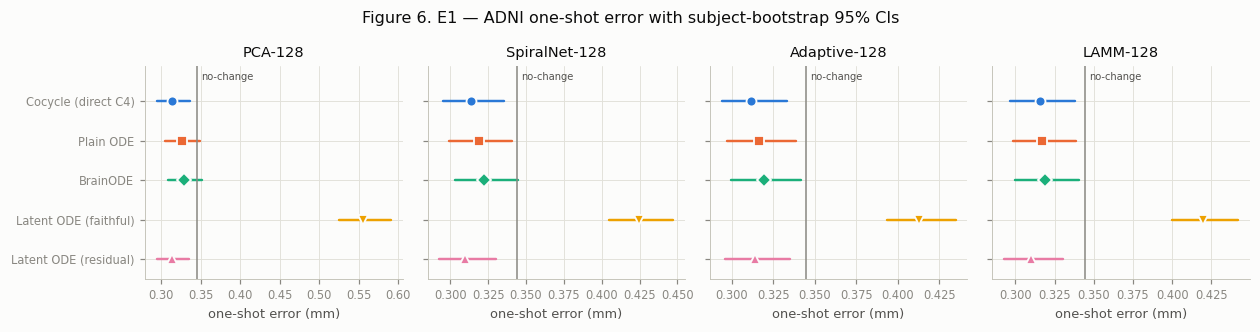

In [12]:
endpoints = R.table_csv("stage5", "endpoints_e1_e4")
p0 = endpoints[endpoints.endpoint_set == "P0 ADNI test"].copy()
p0[["low", "high"]] = p0.E1_ci.str.strip("[]").str.split(",", expand=True).astype(float)
nochange = errors[(errors.model == "baseline:nochange_decoded") & (errors.task == "one_shot_first")].set_index("representation").euclidean_mm_mean
fig, axes = plt.subplots(1, 4, figsize=(11.5, 3.0), sharey=True)
for ax, representation in zip(axes, R.REPS):
    cell = p0[p0.representation == representation].set_index("method")
    for y, method in enumerate(R.METHODS):
        row = cell.loc[method]
        R.interval(ax, y, row.E1_mm, row.low, row.high, R.METHOD_COLOR[method], marker=R.METHOD_MARKER[method])
    ax.axvline(nochange[representation], color=INK["muted"], linewidth=1.0)
    ax.annotate("no-change", (nochange[representation], -0.55), xytext=(3, 0), textcoords="offset points", fontsize=6.5, color=INK["secondary"])
    ax.set_title(R.REP_LABEL[representation])
    ax.set_xlabel("one-shot error (mm)")
axes[0].set_yticks(range(len(R.METHODS)), [R.METHOD_LABEL[m] for m in R.METHODS])
axes[0].set_ylim(len(R.METHODS) - 0.5, -0.9)
fig.suptitle("Figure 6. E1 — ADNI one-shot error with subject-bootstrap 95% CIs")
fig.tight_layout()
plt.show()

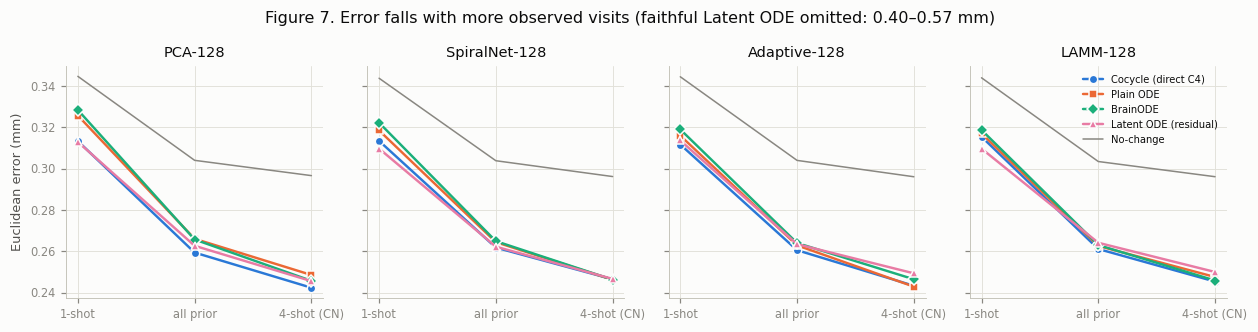

In [13]:
tasks = ["one_shot_first", "all_prior_k", "four_shot"]
fig, axes = plt.subplots(1, 4, figsize=(11.5, 3.0), sharey=True)
for ax, representation in zip(axes, R.REPS):
    for method in SHOWN:
        line = errors[(errors.model == method) & (errors.representation == representation)].set_index("task").reindex(tasks)
        ax.plot(range(3), line.euclidean_mm_mean, color=R.METHOD_COLOR[method], marker=R.METHOD_MARKER[method], markersize=5.5,
                markeredgecolor=INK["surface"], markeredgewidth=1.0, label=R.METHOD_LABEL[method])
    base = errors[(errors.model == "baseline:nochange_decoded") & (errors.representation == representation)].set_index("task").reindex(tasks)
    ax.plot(range(3), base.euclidean_mm_mean, color=INK["muted"], linewidth=1.0, label="No-change")
    ax.set_xticks(range(3), ["1-shot", "all prior", "4-shot (CN)"])
    ax.set_title(R.REP_LABEL[representation])
axes[0].set_ylabel("Euclidean error (mm)")
axes[-1].legend(loc="upper right", fontsize=6.5)
faithful = errors[(errors.model == "latent_ode") & errors.task.isin(tasks)].euclidean_mm_mean
fig.suptitle(f"Figure 7. Error falls with more observed visits (faithful Latent ODE omitted: {faithful.min():.2f}–{faithful.max():.2f} mm)")
fig.tight_layout()
plt.show()

In [14]:
fidelity = R.table_csv("stage3", "p3b_fidelity")
view = fidelity.assign(model=fidelity.model.map(R.METHOD_LABEL), representation=fidelity.representation.map(R.REP_LABEL))
view = view[["representation", "model", "ad_capture_mean", "ad_capture_seed_sd", "cn_capture_mean", "predicted_ad_cn_ratio_mean",
             "observed_ad_cn_ratio_mean", "ad_slope_pearson", "ad_slope_spearman"]]
view.columns = ["representation", "model", "AD capture", "seed SD", "CN capture", "predicted AD/CN rate ratio",
                "observed AD/CN rate ratio", "AD slope r", "AD slope ρ"]
display(R.show(view, "Table 6. Disease fidelity on ADNI test (one-shot; 28 AD and 33 CN subjects)", precision=2))

representation,model,AD capture,seed SD,CN capture,predicted AD/CN rate ratio,observed AD/CN rate ratio,AD slope r,AD slope ρ
Adaptive-128,BrainODE,0.52,0.01,1.18,2.18,4.96,-0.18,-0.19
Adaptive-128,Cocycle (direct C4),0.81,0.10,1.26,3.20,4.96,-0.31,-0.14
Adaptive-128,Latent ODE (faithful),0.93,0.03,0.96,4.92,4.96,-0.25,0.08
Adaptive-128,Latent ODE (residual),0.91,0.05,1.22,3.69,4.96,0.10,0.15
Adaptive-128,Plain ODE,0.42,0.02,1.25,1.67,4.96,-0.35,-0.33
LAMM-128,BrainODE,0.49,0.02,1.22,1.99,4.96,-0.33,-0.31
LAMM-128,Cocycle (direct C4),0.82,0.07,1.21,3.35,4.96,-0.30,-0.18
LAMM-128,Latent ODE (faithful),0.97,0.08,1.03,4.80,4.96,-0.32,-0.02
LAMM-128,Latent ODE (residual),0.84,0.07,1.28,3.31,4.96,0.29,0.33
LAMM-128,Plain ODE,0.54,0.08,1.38,1.93,4.96,-0.45,-0.38


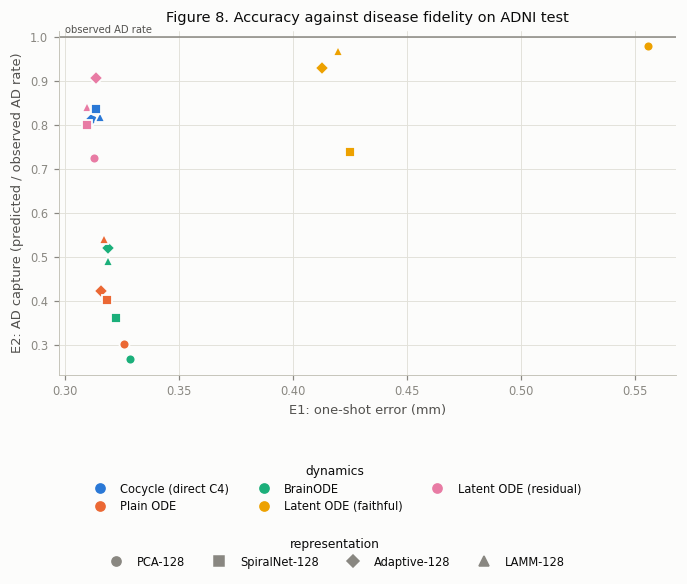

In [15]:
e1 = p0.set_index(["representation", "method"]).E1_mm
fig, ax = plt.subplots(figsize=(6.6, 5.3))
for _, row in fidelity.iterrows():
    R.dot(ax, e1.loc[(row.representation, row.model)], row.ad_capture_mean, R.METHOD_COLOR[row.model], marker=R.REP_MARKER[row.representation])
ax.axhline(1.0, color=INK["muted"], linewidth=1.0)
ax.annotate("observed AD rate", (ax.get_xlim()[0], 1.0), xytext=(4, 3), textcoords="offset points", fontsize=6.5, color=INK["secondary"])
method_handles = [plt.Line2D([], [], color=R.METHOD_COLOR[m], marker="o", linestyle="none", markersize=6) for m in R.METHODS]
rep_handles = [plt.Line2D([], [], color=INK["muted"], marker=R.REP_MARKER[r], linestyle="none", markersize=6) for r in R.REPS]
ax.set_xlabel("E1: one-shot error (mm)")
ax.set_ylabel("E2: AD capture (predicted / observed AD rate)")
ax.set_title("Figure 8. Accuracy against disease fidelity on ADNI test")
fig.subplots_adjust(left=0.12, right=0.97, top=0.93, bottom=0.34)
fig.legend(method_handles, [R.METHOD_LABEL[m] for m in R.METHODS], loc="lower center", bbox_to_anchor=(0.5, 0.085), ncol=3, title="dynamics")
fig.legend(rep_handles, [R.REP_LABEL[r] for r in R.REPS], loc="lower center", bbox_to_anchor=(0.5, -0.01), ncol=4, title="representation")
plt.show()

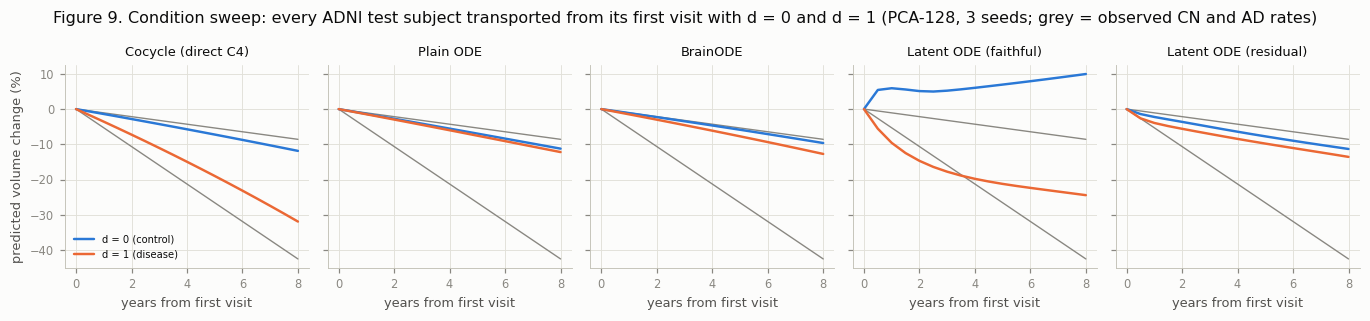

In [16]:
frames = []
for method in R.METHODS:
    for seed in (42, 43, 44):
        frames.append(pd.read_csv(R.STAGE3 / "condition_sweeps" / f"pca128__{method}__s{seed}.csv").assign(method=method, seed=seed))
curves = pd.concat(frames).groupby(["method", "condition", "horizon_years"]).log_change_from_h0.mean().reset_index()
observed = R.read_json(R.STAGE3 / "condition_sweeps" / "pca128__direct_c4__s42.json")["groups"]
cn_rate, ad_rate = observed["CN"]["observed_first_last_log_rate_mean"], observed["AD"]["observed_first_last_log_rate_mean"]
fig, axes = plt.subplots(1, 5, figsize=(12.5, 2.9), sharey=True)
for ax, method in zip(axes, R.METHODS):
    horizon = np.array([0.0, 8.0])
    ax.plot(horizon, 100 * cn_rate * horizon, color=INK["muted"], linewidth=0.9)
    ax.plot(horizon, 100 * ad_rate * horizon, color=INK["muted"], linewidth=0.9)
    for condition, color, label in ((0, SLOTS[0], "d = 0 (control)"), (1, SLOTS[1], "d = 1 (disease)")):
        line = curves[(curves.method == method) & (curves.condition == condition)]
        ax.plot(line.horizon_years, 100 * line.log_change_from_h0, color=color, label=label)
    ax.set_title(R.METHOD_LABEL[method], fontsize=8.5)
    ax.set_xlabel("years from first visit")
axes[0].set_ylabel("predicted volume change (%)")
axes[0].legend(loc="lower left", fontsize=6.5)
fig.suptitle("Figure 9. Condition sweep: every ADNI test subject transported from its first visit with d = 0 and d = 1 "
             "(PCA-128, 3 seeds; grey = observed CN and AD rates)")
fig.tight_layout()
plt.show()

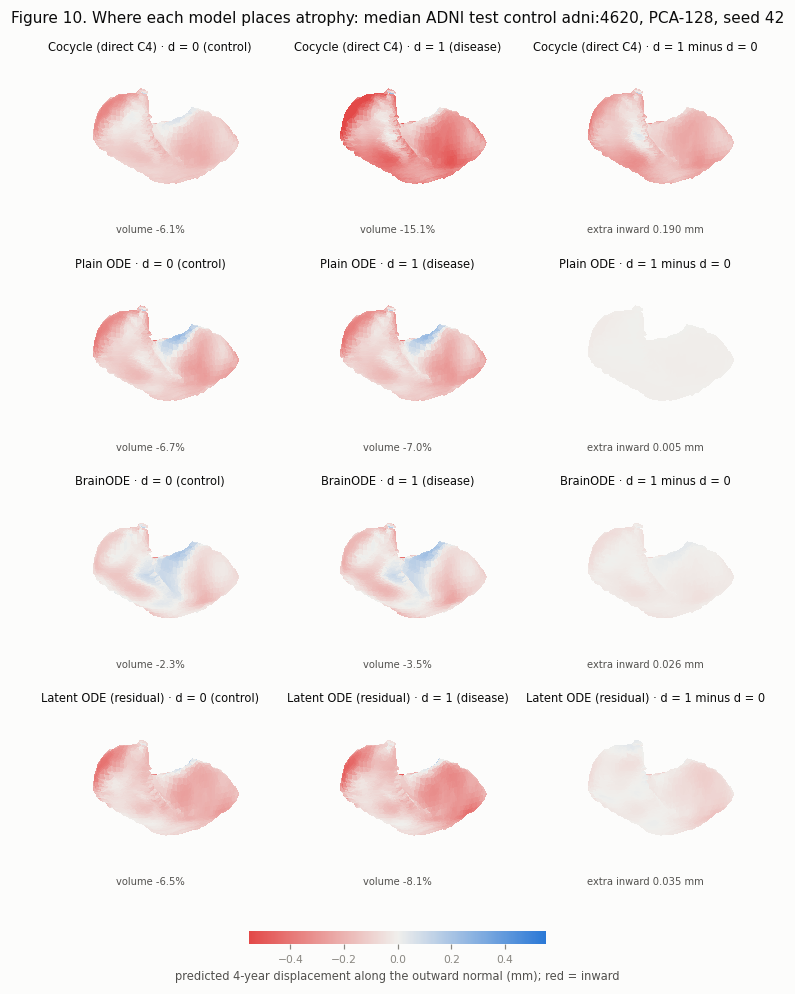

In [17]:
panels, vmax, subject = R.condition_sweep_panels(years=4.0)
fig = R.render_meshes(panels, ncols=3, cmap=R.diverging_cmap(), norm=TwoSlopeNorm(0.0, -vmax, vmax),
                      colorbar_label="predicted 4-year displacement along the outward normal (mm); red = inward",
                      title=f"Figure 10. Where each model places atrophy: median ADNI test control {subject}, PCA-128, seed 42")
plt.show()

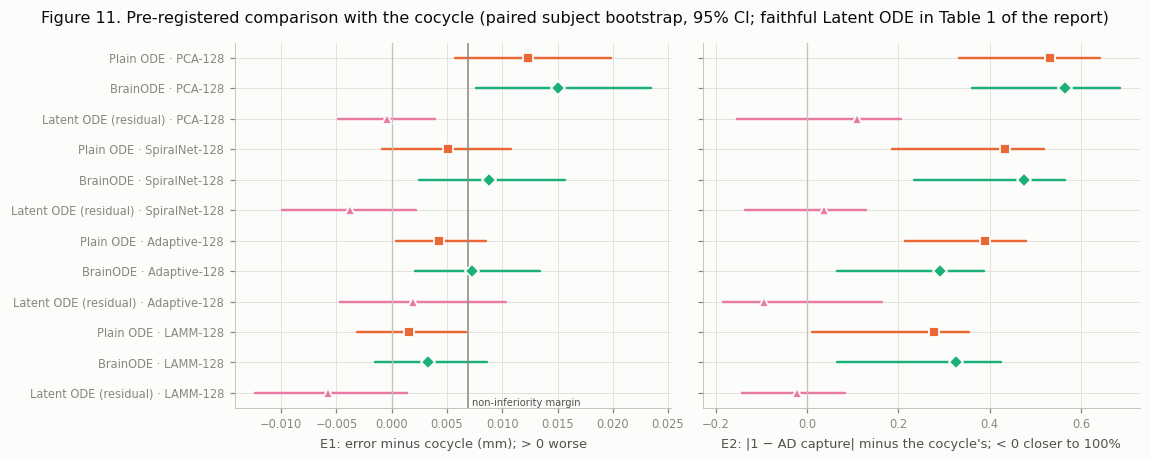

- **PCA-128:** no method is preferred over the cocycle; ranking follows E1. E1 order: Latent ODE (residual) 0.3130 mm; Cocycle (direct C4) 0.3134 mm; Plain ODE 0.3258 mm; BrainODE 0.3285 mm; Latent ODE (faithful) 0.5556 mm
- **SpiralNet-128:** no method is preferred over the cocycle; ranking follows E1. E1 order: Latent ODE (residual) 0.3098 mm; Cocycle (direct C4) 0.3135 mm; Plain ODE 0.3186 mm; BrainODE 0.3223 mm; Latent ODE (faithful) 0.4249 mm
- **Adaptive-128:** no method is preferred over the cocycle; ranking follows E1. E1 order: Cocycle (direct C4) 0.3117 mm; Latent ODE (residual) 0.3137 mm; Plain ODE 0.3160 mm; BrainODE 0.3191 mm; Latent ODE (faithful) 0.4128 mm
- **LAMM-128:** no method is preferred over the cocycle; ranking follows E1. E1 order: Latent ODE (residual) 0.3098 mm; Cocycle (direct C4) 0.3155 mm; Plain ODE 0.3171 mm; BrainODE 0.3188 mm; Latent ODE (faithful) 0.4199 mm

In [18]:
decisions = next(g for g in R.read_json(R.STAGE5 / "reports" / "gates.json")["gates"] if g["id"] == "G5.3")["detail"]
paired = p0[p0.method.isin(["plain_ode", "brainode", "latent_ode_residual"])].copy()
for column in ("dE1_ci", "dE2_ci"):
    paired[[f"{column}_low", f"{column}_high"]] = paired[column].str.strip("[]").str.split(",", expand=True).astype(float)
margin = np.mean([d["margin_mm"] for d in decisions])
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), sharey=True)
labels = []
for y, row in enumerate(paired.itertuples()):
    labels.append(f"{R.METHOD_LABEL[row.method]} · {R.REP_LABEL[row.representation]}")
    R.interval(axes[0], y, row.dE1_vs_cocycle_mm, row.dE1_ci_low, row.dE1_ci_high, R.METHOD_COLOR[row.method], marker=R.METHOD_MARKER[row.method])
    R.interval(axes[1], y, row.dE2_distance_to_100pct, row.dE2_ci_low, row.dE2_ci_high, R.METHOD_COLOR[row.method], marker=R.METHOD_MARKER[row.method])
axes[0].axvline(0.0, color=INK["baseline"], linewidth=0.9)
axes[0].axvline(margin, color=INK["muted"], linewidth=1.0)
axes[0].annotate("non-inferiority margin", (margin, len(labels) - 0.6), xytext=(3, 0), textcoords="offset points", fontsize=6.5, color=INK["secondary"])
axes[1].axvline(0.0, color=INK["baseline"], linewidth=0.9)
axes[0].set_yticks(range(len(labels)), labels)
axes[0].set_ylim(len(labels) - 0.5, -0.5)
axes[0].set_xlabel("E1: error minus cocycle (mm); > 0 worse")
axes[1].set_xlabel("E2: |1 − AD capture| minus the cocycle's; < 0 closer to 100%")
fig.suptitle("Figure 11. Pre-registered comparison with the cocycle (paired subject bootstrap, 95% CI; faithful Latent ODE in Table 1 of the report)")
fig.tight_layout()
plt.show()
def ranked(entry):
    method, value = entry.split(" ")
    return f"{R.METHOD_LABEL[method]} {value.strip('()')} mm"
display(Markdown("\n".join(f"- **{R.REP_LABEL[d['representation']]}:** {d['decision']}. E1 order: {'; '.join(ranked(e) for e in d['ranking_by_E1'])}"
                            for d in decisions)))

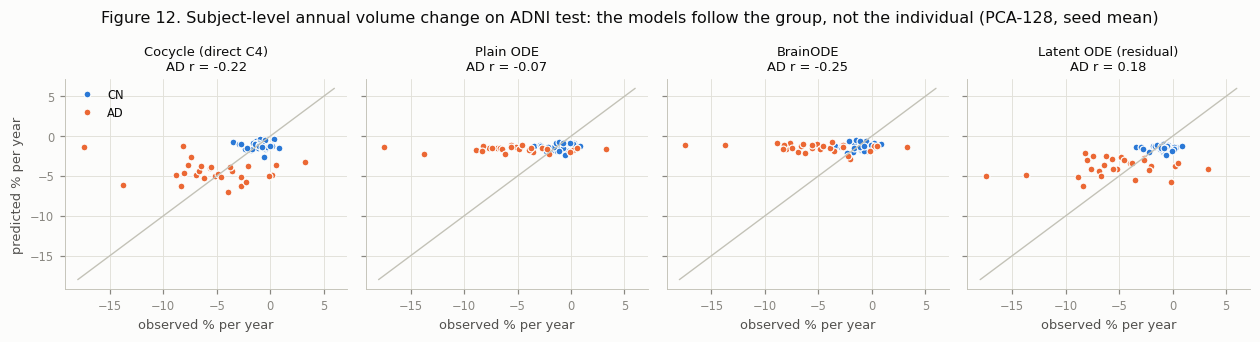

In [19]:
frames = []
for method in SHOWN:
    for seed in (42, 43, 44):
        rows = pd.read_csv(Path(R.stage3_run(method, seed=seed)["evaluations"]["test"]) / "task_rows.csv", dtype={"subject_id": str})
        frames.append(rows[(rows.task == "one_shot_first") & (rows.variant == "averaged")].assign(method=method))
slopes = pd.concat(frames).groupby(["method", "subject_id", "diagnosis"])[["predicted_log_volume_rate", "observed_log_volume_rate"]].mean().reset_index()
fig, axes = plt.subplots(1, 4, figsize=(11.5, 3.1), sharex=True, sharey=True)
for ax, method in zip(axes, SHOWN):
    for diagnosis, color in (("CN", SLOTS[0]), ("AD", SLOTS[1])):
        cell = slopes[(slopes.method == method) & (slopes.diagnosis == diagnosis)]
        ax.plot(100 * cell.observed_log_volume_rate, 100 * cell.predicted_log_volume_rate, "o", color=color, markersize=4.5,
                markeredgecolor=INK["surface"], markeredgewidth=0.8, linestyle="none", label=diagnosis)
    ax.plot([-18, 6], [-18, 6], color=INK["baseline"], linewidth=0.9)
    ad = slopes[(slopes.method == method) & (slopes.diagnosis == "AD")]
    ax.set_title(f"{R.METHOD_LABEL[method]}\nAD r = {np.corrcoef(ad.observed_log_volume_rate, ad.predicted_log_volume_rate)[0, 1]:.2f}", fontsize=8.5)
    ax.set_xlabel("observed % per year")
axes[0].set_ylabel("predicted % per year")
axes[0].legend(loc="upper left")
fig.suptitle("Figure 12. Subject-level annual volume change on ADNI test: the models follow the group, not the individual (PCA-128, seed mean)")
fig.tight_layout()
plt.show()

In [20]:
consistency = R.table_csv("stage3", "p3cd_consistency_horizons")
view = consistency.assign(model=consistency.model.map(R.METHOD_LABEL), representation=consistency.representation.map(R.REP_LABEL))
view.columns = ["representation", "model", "semigroup defect", "inverse defect", "training (min)", "best epoch",
                "error ≤ 1 y (mm)", "error 1–2 y (mm)", "error > 2 y (mm)"]
display(R.show(view, "Table 7. Consistency, cost and error by horizon (ADNI test pair metrics, seed mean)", precision=4,
               formats={"semigroup defect": "{:.1e}", "inverse defect": "{:.1e}", "training (min)": "{:.1f}", "best epoch": "{:.0f}"}))

representation,model,semigroup defect,inverse defect,training (min),best epoch,error ≤ 1 y (mm),error 1–2 y (mm),error > 2 y (mm)
Adaptive-128,BrainODE,2.5e-07,5.9e-08,72.8,14,0.2880,0.3072,0.3285
Adaptive-128,Cocycle (direct C4),3.9e-03,1.6e-02,48.7,1,0.2872,0.3052,0.3209
Adaptive-128,Latent ODE (faithful),2.4e-01,1.4e+00,15.4,23,0.3945,0.4063,0.4449
Adaptive-128,Latent ODE (residual),1.0e-01,2.9e+00,18.0,31,0.2831,0.2993,0.3180
Adaptive-128,Plain ODE,2.4e-07,5.2e-08,9.0,4,0.2881,0.3060,0.3221
LAMM-128,BrainODE,2.1e-07,4.7e-08,4.8,15,0.2877,0.3075,0.3262
LAMM-128,Cocycle (direct C4),4.5e-03,1.8e-02,10.0,21,0.2873,0.3061,0.3249
LAMM-128,Latent ODE (faithful),2.3e-01,1.4e+00,15.7,23,0.3965,0.4129,0.4519
LAMM-128,Latent ODE (residual),1.6e-01,3.7e+00,24.9,61,0.2794,0.2943,0.3158
LAMM-128,Plain ODE,2.4e-07,6.0e-08,8.0,9,0.2874,0.3063,0.3311


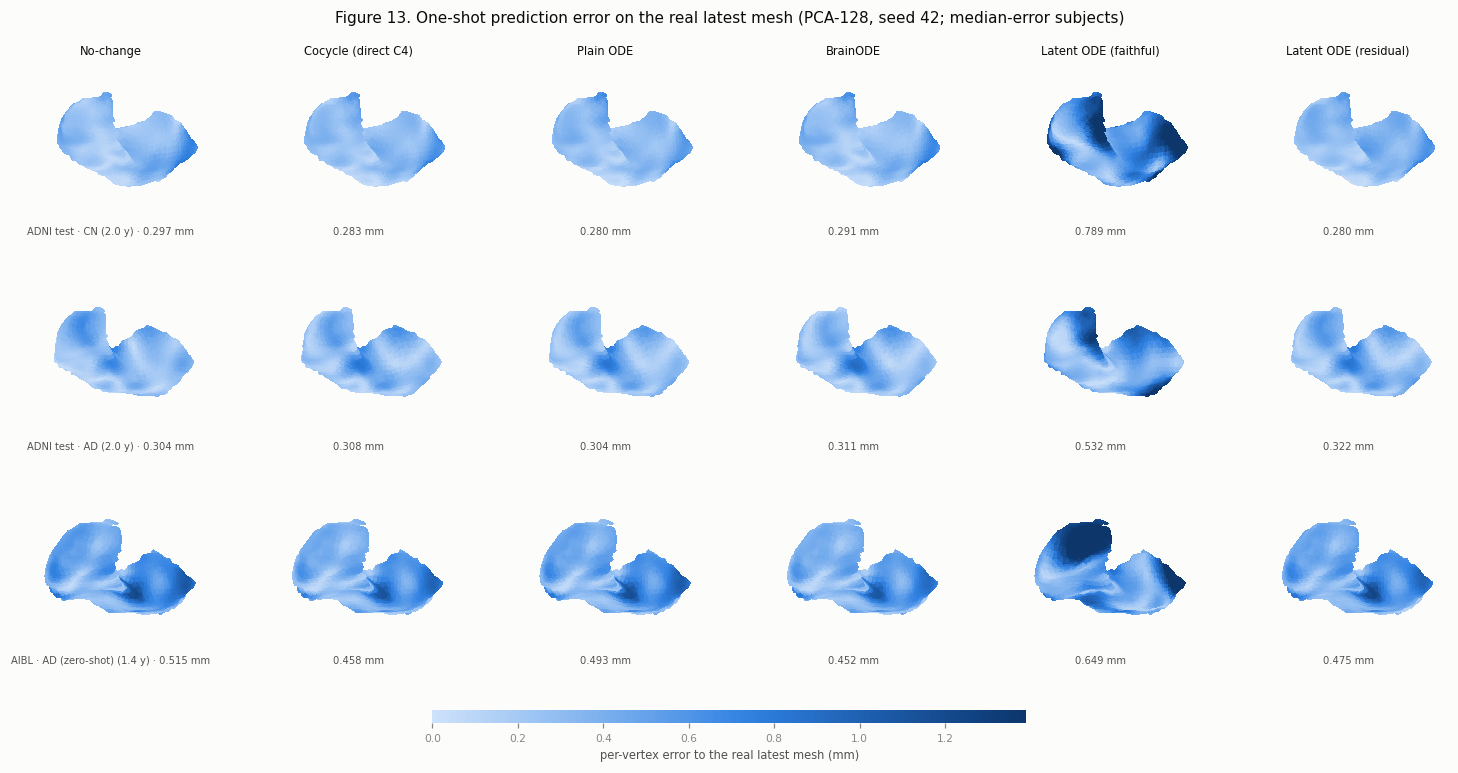

In [21]:
panels, vmax = R.one_shot_error_panels()
fig = R.render_meshes(panels, ncols=6, cmap=R.sequential_cmap(), norm=Normalize(0.0, vmax),
                      colorbar_label="per-vertex error to the real latest mesh (mm)",
                      title="Figure 13. One-shot prediction error on the real latest mesh (PCA-128, seed 42; median-error subjects)")
plt.show()

## 6. Cross-cohort transfer

Skill is always computed against no-change on the same subjects and representation, because the protocols evaluate
different subject sets (test split, whole cohort, out-of-fold).

In [22]:
per_dataset = R.table_csv("stage5", "r_t7_per_dataset")
summary = (per_dataset.groupby(["cohort", "scope", "method"]).skill.mean().unstack("method")[list(R.METHODS)] * 100).reset_index()
summary["cohort"] = pd.Categorical(summary.cohort.map(R.COHORT_LABEL), [R.COHORT_LABEL[c] for c in R.COHORTS], ordered=True)
summary = summary.sort_values(["cohort", "scope"]).rename(columns={"scope": "protocol", **R.METHOD_LABEL})
display(R.show(summary, "Table 8. One-shot skill vs no-change (%, mean over the four representations)", precision=1,
               formats={R.METHOD_LABEL[m]: "{:+.1f}" for m in R.METHODS}))

cohort,protocol,Cocycle (direct C4),Plain ODE,BrainODE,Latent ODE (faithful),Latent ODE (residual)
ADNI,P0 internal (test split),+8.9,+7.2,+6.4,-31.6,+9.5
ADNI,P3 pooled (test split),+9.3,+7.6,+7.5,-24.3,+10.0
ADNI,P4 LOCO (whole cohort),+0.8,+5.7,+5.2,-52.0,+6.2
AIBL,P1 zero-shot (test split),+2.2,+0.9,-0.2,-37.1,+2.0
AIBL,P1 zero-shot (whole cohort),+5.1,+4.4,+3.5,-31.2,+6.3
AIBL,"P2 cross-fit (whole, out-of-fold)",+3.4,+4.1,+3.8,-54.8,+3.8
AIBL,P2 internal (test split),-0.5,+0.8,+1.3,-52.1,-2.2
AIBL,P3 pooled (test split),+2.6,+0.3,+0.9,-28.4,+2.6
AIBL,P4 LOCO (whole cohort),+5.5,+5.0,+4.5,-21.7,+7.0
OASIS-3,P1 zero-shot (test split),+2.8,+1.8,-1.1,-42.3,+1.8


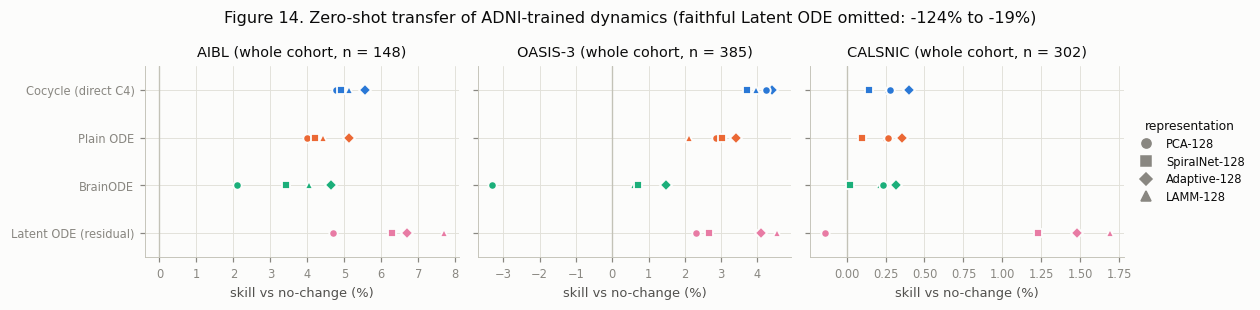

In [23]:
zero = per_dataset[per_dataset.scope == "P1 zero-shot (whole cohort)"]
fig, axes = plt.subplots(1, 3, figsize=(11.5, 2.8), sharey=True)
for ax, cohort in zip(axes, ("aibl", "oasis", "calsnic")):
    for y, method in enumerate(SHOWN):
        for _, row in zero[(zero.cohort == cohort) & (zero.method == method)].iterrows():
            R.dot(ax, 100 * row.skill, y, R.METHOD_COLOR[method], marker=R.REP_MARKER[row.representation], size=5.5)
    ax.axvline(0, color=INK["baseline"], linewidth=0.9)
    subjects = int(zero[zero.cohort == cohort].subjects.max())
    ax.set_title(f"{R.COHORT_LABEL[cohort]} (whole cohort, n = {subjects})")
    ax.set_xlabel("skill vs no-change (%)")
axes[0].set_yticks(range(len(SHOWN)), [R.METHOD_LABEL[m] for m in SHOWN])
axes[0].set_ylim(len(SHOWN) - 0.5, -0.5)
handles = [plt.Line2D([], [], color=INK["muted"], marker=R.REP_MARKER[r], linestyle="none", markersize=6) for r in R.REPS]
axes[-1].legend(handles, [R.REP_LABEL[r] for r in R.REPS], loc="center left", bbox_to_anchor=(1.0, 0.5), title="representation")
faithful = 100 * zero[zero.method == "latent_ode"].skill
fig.suptitle(f"Figure 14. Zero-shot transfer of ADNI-trained dynamics (faithful Latent ODE omitted: {faithful.min():.0f}% to {faithful.max():.0f}%)")
fig.tight_layout()
plt.show()

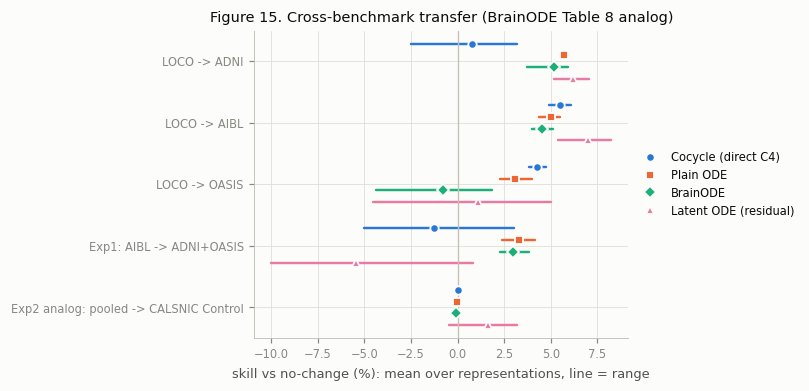

In [24]:
cross = R.table_csv("stage5", "r_t8_cross_benchmark")
benchmarks = list(dict.fromkeys(cross.benchmark))
fig, ax = plt.subplots(figsize=(7.4, 3.6))
for j, method in enumerate(SHOWN):
    for i, benchmark in enumerate(benchmarks):
        values = 100 * cross[(cross.benchmark == benchmark) & (cross.method == method)].skill
        R.interval(ax, i + (j - 1.5) * 0.19, values.mean(), values.min(), values.max(), R.METHOD_COLOR[method],
                   marker=R.METHOD_MARKER[method], label=R.METHOD_LABEL[method] if i == 0 else None, size=5.5)
ax.axvline(0, color=INK["baseline"], linewidth=0.9)
ax.set_yticks(range(len(benchmarks)), benchmarks)
ax.set_ylim(len(benchmarks) - 0.5, -0.5)
ax.set_xlabel("skill vs no-change (%): mean over representations, line = range")
ax.set_title("Figure 15. Cross-benchmark transfer (BrainODE Table 8 analog)")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
fig.tight_layout()
plt.show()

In [25]:
unified = R.table_csv("stage5", "r_t2_unified")
wide = unified.pivot_table(index="method", columns="task", values="euclidean_mean", aggfunc="mean").reindex(list(R.METHODS))
counts = unified.groupby("task").subjects.max()
task_names = {"one_shot_first": "one-shot", "all_prior_k": "all prior (k ≤ 4)", "four_shot": "4-shot"}
wide.columns = [f"{task_names.get(task, task)} (n = {counts[task]})" for task in wide.columns]
display(R.show(wide.rename(index=R.METHOD_LABEL).reset_index(), "Table 9. Unified pooled test, ADNI + AIBL + OASIS-3 (P3; mm, mean over representations)", precision=4))

method,all prior (k ≤ 4) (n = 89),4-shot (n = 26),one-shot (n = 115)
Cocycle (direct C4),0.2850,0.2582,0.3548
Plain ODE,0.2885,0.2609,0.3613
BrainODE,0.2885,0.2605,0.3616
Latent ODE (faithful),0.4413,0.4293,0.4762
Latent ODE (residual),0.2895,0.2634,0.3528


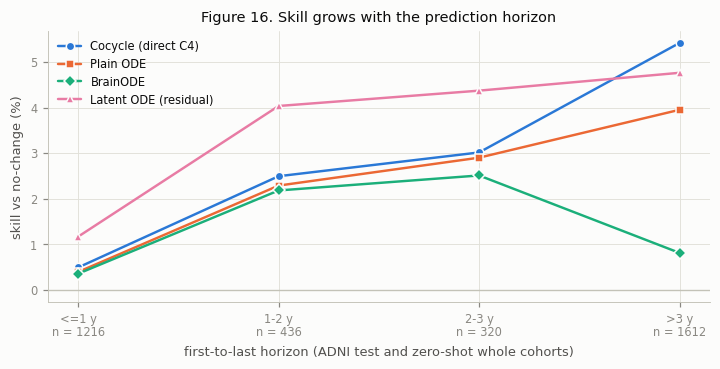

In [26]:
horizons = R.table_csv("stage4", "s4f_interval_shift")
order = ["<=1 y", "1-2 y", "2-3 y", ">3 y"]
counts = horizons.groupby("horizon_bin").subjects.max().reindex(order)
fig, ax = plt.subplots(figsize=(6.6, 3.4))
for method in SHOWN:
    line = horizons[horizons.method == method].set_index("horizon_bin").reindex(order)
    ax.plot(range(4), 100 * line.skill, color=R.METHOD_COLOR[method], marker=R.METHOD_MARKER[method], markersize=5.5,
            markeredgecolor=INK["surface"], markeredgewidth=1.0, label=R.METHOD_LABEL[method])
ax.axhline(0, color=INK["baseline"], linewidth=0.9)
ax.set_xticks(range(4), [f"{b}\nn = {n}" for b, n in counts.items()])
ax.set_xlabel("first-to-last horizon (ADNI test and zero-shot whole cohorts)")
ax.set_ylabel("skill vs no-change (%)")
ax.set_title("Figure 16. Skill grows with the prediction horizon")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

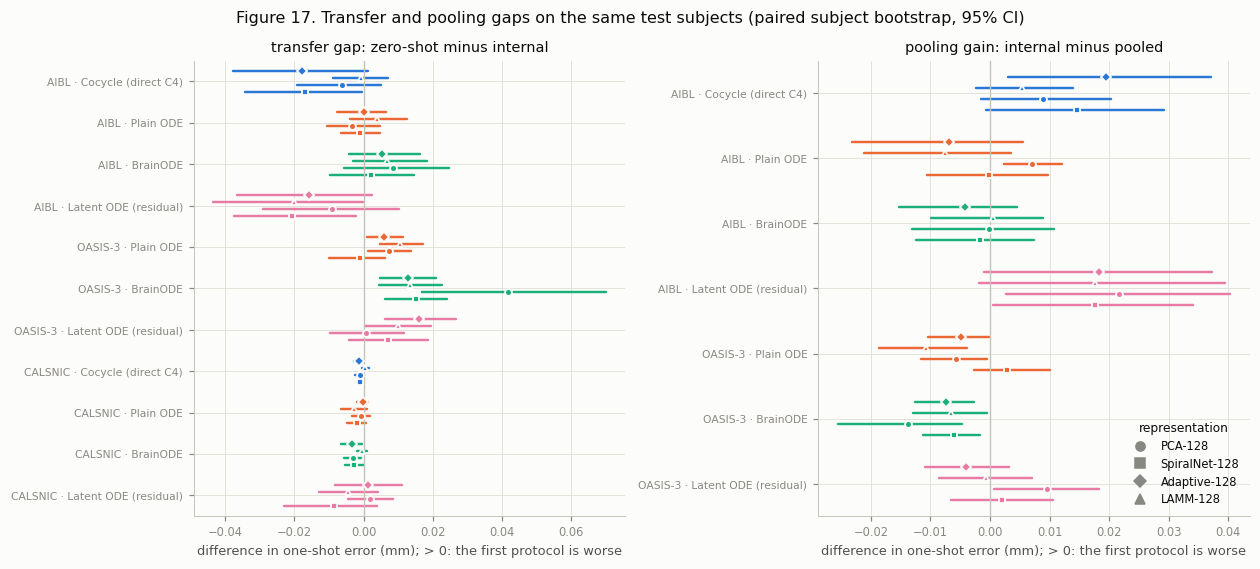

In [27]:
gaps = R.table_csv("stage4", "s4e_gaps")
comparisons = ["transfer gap: zero-shot minus internal", "pooling gain: internal minus pooled"]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.2))
for ax, comparison in zip(axes, comparisons):
    part = gaps[(gaps.comparison == comparison) & gaps.method.isin(SHOWN)]
    rows = [(c, m) for c in ("aibl", "oasis", "calsnic") for m in SHOWN if ((part.cohort == c) & (part.method == m)).any()]
    for y, (cohort, method) in enumerate(rows):
        cell = part[(part.cohort == cohort) & (part.method == method)].reset_index(drop=True)
        for k, row in cell.iterrows():
            R.interval(ax, y + (k - 1.5) * 0.17, row.mean_difference, row.ci95_low, row.ci95_high, R.METHOD_COLOR[method],
                       marker=R.REP_MARKER[row.representation], size=4.5)
    ax.axvline(0, color=INK["baseline"], linewidth=0.9)
    ax.set_yticks(range(len(rows)), [f"{R.COHORT_LABEL[c]} · {R.METHOD_LABEL[m]}" for c, m in rows], fontsize=7)
    ax.set_ylim(len(rows) - 0.5, -0.5)
    ax.set_title(comparison)
    ax.set_xlabel("difference in one-shot error (mm); > 0: the first protocol is worse")
handles = [plt.Line2D([], [], color=INK["muted"], marker=R.REP_MARKER[r], linestyle="none", markersize=6) for r in R.REPS]
axes[-1].legend(handles, [R.REP_LABEL[r] for r in R.REPS], loc="lower right", title="representation")
fig.suptitle("Figure 17. Transfer and pooling gaps on the same test subjects (paired subject bootstrap, 95% CI)")
fig.tight_layout()
plt.show()

In [28]:
external = R.table_csv("stage4", "s4g_ad_fidelity")
part = external[external.scope.str.contains("whole|out-of-fold")]
wide = part.groupby(["cohort", "scope", "method"]).ad_capture.mean().unstack("method").reindex(columns=list(R.METHODS))
wide.insert(0, "AD subjects", part.groupby(["cohort", "scope"]).ad_subjects.max())
wide = wide.reset_index().rename(columns={"scope": "protocol", **R.METHOD_LABEL})
wide["cohort"] = wide.cohort.map(R.COHORT_LABEL)
display(R.show(wide, "Table 10. AD capture outside ADNI (whole cohorts and out-of-fold; OASIS-3 has 6 AD subjects, descriptive only)", precision=2,
               formats={"AD subjects": "{:.0f}"}))

cohort,protocol,AD subjects,Cocycle (direct C4),Plain ODE,BrainODE,Latent ODE (faithful),Latent ODE (residual)
AIBL,P1 zero-shot (whole cohort),20,0.71,0.38,0.48,1.19,0.73
AIBL,"P2 cross-fit (whole, out-of-fold)",20,0.69,0.37,0.37,-0.51,0.74
AIBL,P4 LOCO (whole cohort),20,0.76,0.49,0.48,1.00,0.53
OASIS-3,P1 zero-shot (whole cohort),6,0.75,0.40,0.53,1.39,0.77
OASIS-3,"P2 cross-fit (whole, out-of-fold)",6,–,0.21,0.21,-1.28,0.37
OASIS-3,P4 LOCO (whole cohort),6,0.80,0.38,0.61,1.00,0.82


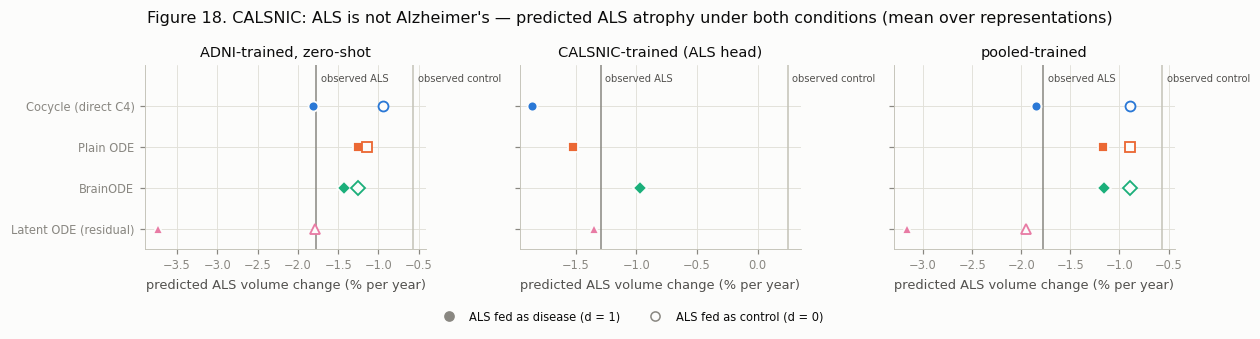

In [29]:
ood = R.table_csv("stage4", "s4h_calsnic_ood")
views = [("p1_external_calsnic_wholecohort", "ADNI-trained, zero-shot"), ("p2_internal_calsnic", "CALSNIC-trained (ALS head)"),
         ("p4c_exp2_pooled_to_calsnic", "pooled-trained")]
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.0), sharey=True)
for ax, (view_name, title) in zip(axes, views):
    part = ood[ood.view == view_name]
    for y, method in enumerate(SHOWN):
        for condition, filled in (("labels (ALS = disease)", True), ("all d = 0", False)):
            cell = part[(part.method == method) & (part.condition == condition)]
            if len(cell):
                R.dot(ax, 100 * cell.als_predicted_rate.mean(), y, R.METHOD_COLOR[method], marker=R.METHOD_MARKER[method], filled=filled)
    for value, text, color in ((100 * part.als_observed_rate.mean(), "observed ALS", INK["muted"]), (100 * part.control_observed_rate.mean(), "observed control", INK["baseline"])):
        ax.axvline(value, color=color, linewidth=1.0)
        ax.annotate(text, (value, -0.6), xytext=(3, 0), textcoords="offset points", fontsize=6.5, color=INK["secondary"])
    ax.set_title(title)
    ax.set_xlabel("predicted ALS volume change (% per year)")
axes[0].set_yticks(range(len(SHOWN)), [R.METHOD_LABEL[m] for m in SHOWN])
axes[0].set_ylim(len(SHOWN) - 0.5, -1.0)
handles = [plt.Line2D([], [], color=INK["muted"], marker="o", linestyle="none"),
           plt.Line2D([], [], color=INK["muted"], marker="o", markerfacecolor=INK["surface"], linestyle="none")]
fig.legend(handles, ["ALS fed as disease (d = 1)", "ALS fed as control (d = 0)"], loc="lower center", ncol=2, bbox_to_anchor=(0.5, 0.0))
fig.suptitle("Figure 18. CALSNIC: ALS is not Alzheimer's — predicted ALS atrophy under both conditions (mean over representations)")
fig.tight_layout(rect=(0, 0.09, 1, 1))
plt.show()

## 7. Ablations (ADNI test, one-shot)

A1: exact and volume coboundary cocycles trained to completion (no early stopping). A2: BrainODE's vector field
trained with the cocycle's full objective. A3: the cocycle with the disease head removed. A4: Latent ODEs without the
condition. References are the stage 3 models.

In [30]:
ablations = R.table_csv("stage5", "r_t3_ablations")
names = {"reference direct_c4": "Cocycle (reference)", "reference plain_ode": "Plain ODE (reference)", "reference brainode": "BrainODE (reference)",
         "reference latent_ode": "Latent ODE faithful (reference)", "reference latent_ode_residual": "Latent ODE residual (reference)",
         "A1 exact_coboundary_c4": "A1 exact coboundary cocycle", "A1 volume_exact_coboundary_c4_v2": "A1 volume coboundary cocycle v2",
         "A2 brainode_v": "A2 BrainODE field + cocycle loss", "A3 direct_c4_no_disease": "A3 cocycle without disease head",
         "A4 latent_ode": "A4 faithful Latent ODE without condition", "A4 latent_ode_residual": "A4 residual Latent ODE without condition"}
order = list(names)
table = ablations.assign(order=ablations.row.map(order.index), model=ablations.row.map(names), representation=ablations.representation.map(R.REP_LABEL))
table = table.sort_values(["order", "representation"])[["model", "representation", "seeds", "euclidean_mm", "ad_capture", "condition_share_of_gap",
                                                         "semigroup_defect", "best_epoch", "epochs_run", "train_minutes"]]
table.columns = ["model", "representation", "seeds", "one-shot error (mm)", "AD capture", "condition share of AD–CN gap",
                 "semigroup defect", "best epoch", "epochs run", "training (min)"]
display(R.show(table, "Table 11. Ablations A1–A4 against the stage 3 references", precision=3,
               formats={"semigroup defect": "{:.1e}", "best epoch": "{:.0f}", "epochs run": "{:.0f}", "training (min)": "{:.0f}", "seeds": "{:.0f}"}))

model,representation,seeds,one-shot error (mm),AD capture,condition share of AD–CN gap,semigroup defect,best epoch,epochs run,training (min)
Cocycle (reference),PCA-128,3,0.313,0.835,0.519,4.7e-04,5,45,3
Cocycle (reference),SpiralNet-128,3,0.314,0.837,0.424,1.3e-03,1,41,27
Plain ODE (reference),PCA-128,3,0.326,0.303,0.027,2.0e-07,17,100,8
BrainODE (reference),PCA-128,3,0.328,0.269,0.084,1.7e-07,48,100,72
Latent ODE faithful (reference),PCA-128,3,0.556,0.978,2.754,1.9e-01,18,43,14
Latent ODE residual (reference),PCA-128,3,0.313,0.724,0.285,6.4e-02,12,37,12
A1 exact coboundary cocycle,PCA-128,1,0.329,0.171,0.055,1.4e-07,3,180,59
A1 exact coboundary cocycle,SpiralNet-128,1,0.325,0.212,0.063,1.7e-07,28,180,265
A1 volume coboundary cocycle v2,PCA-128,1,0.325,0.169,0.023,3.5e-07,2,160,49
A1 volume coboundary cocycle v2,SpiralNet-128,1,0.321,0.187,0.043,4.2e-07,1,160,201


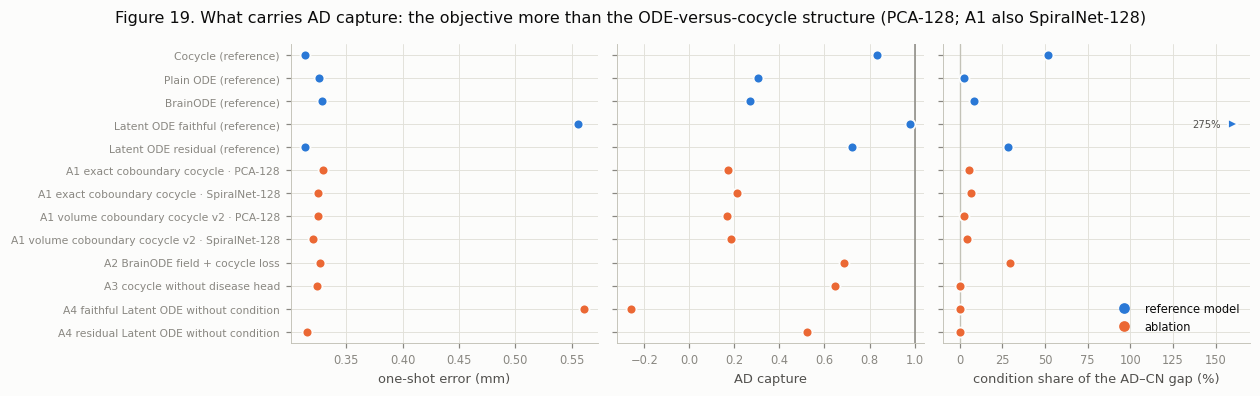

In [31]:
pca = table[(table.representation == "PCA-128") | table.model.str.startswith("A1")]
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.6), sharey=True)
labels = [f"{m} · {r}" if m.startswith("A1") else m for m, r in zip(pca.model, pca.representation)]
for y, (_, row) in enumerate(pca.iterrows()):
    color = SLOTS[0] if "reference" in row.model else SLOTS[1]
    R.dot(axes[0], row["one-shot error (mm)"], y, color)
    R.dot(axes[1], row["AD capture"], y, color)
    share = 100 * row["condition share of AD–CN gap"]
    if share > 160:  # off-scale: drawn at the cap with its value
        R.dot(axes[2], 160, y, color, marker=">")
        axes[2].annotate(f"{share:.0f}%", (160, y), xytext=(-8, 0), textcoords="offset points", ha="right", va="center",
                         fontsize=6.5, color=INK["secondary"])
    else:
        R.dot(axes[2], share, y, color)
axes[1].axvline(1.0, color=INK["muted"], linewidth=1.0)
axes[2].axvline(0.0, color=INK["baseline"], linewidth=0.9)
axes[2].set_xlim(-10, 170)
for ax, xlabel in zip(axes, ("one-shot error (mm)", "AD capture", "condition share of the AD–CN gap (%)")):
    ax.set_xlabel(xlabel)
axes[0].set_yticks(range(len(labels)), labels, fontsize=7)
axes[0].set_ylim(len(labels) - 0.5, -0.5)
handles = [plt.Line2D([], [], color=SLOTS[0], marker="o", linestyle="none"), plt.Line2D([], [], color=SLOTS[1], marker="o", linestyle="none")]
axes[-1].legend(handles, ["reference model", "ablation"], loc="lower right")
fig.suptitle("Figure 19. What carries AD capture: the objective more than the ODE-versus-cocycle structure (PCA-128; A1 also SpiralNet-128)")
fig.tight_layout()
plt.show()

## 8. Sensitivity analyses

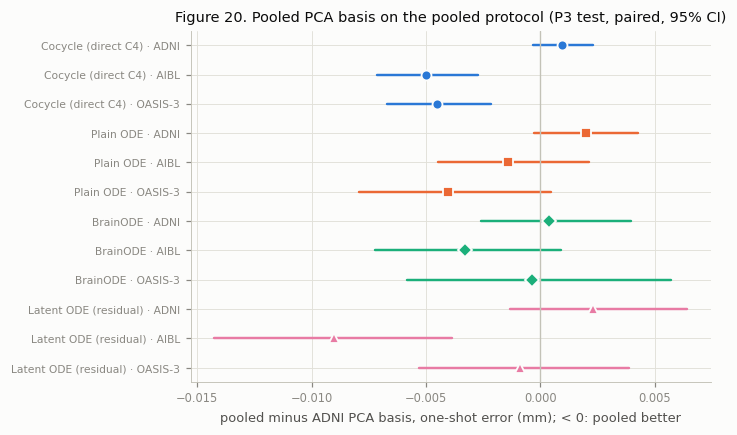

In [32]:
pooled = R.table_csv("stage5", "sensitivity_pooled_pca")
part = pooled[(pooled.task == "one_shot_first") & pooled.method.isin(SHOWN)]
rows = [(m, c) for m in SHOWN for c in ("adni", "aibl", "oasis")]
fig, ax = plt.subplots(figsize=(6.6, 4.0))
for y, (method, cohort) in enumerate(rows):
    row = part[(part.method == method) & (part.cohort == cohort)].iloc[0]
    R.interval(ax, y, row.mean_difference, row.ci95_low, row.ci95_high, R.METHOD_COLOR[method], marker=R.METHOD_MARKER[method])
ax.axvline(0, color=INK["baseline"], linewidth=0.9)
ax.set_yticks(range(len(rows)), [f"{R.METHOD_LABEL[m]} · {R.COHORT_LABEL[c]}" for m, c in rows], fontsize=7)
ax.set_ylim(len(rows) - 0.5, -0.5)
ax.set_xlabel("pooled minus ADNI PCA basis, one-shot error (mm); < 0: pooled better")
ax.set_title("Figure 20. Pooled PCA basis on the pooled protocol (P3 test, paired, 95% CI)")
fig.tight_layout()
plt.show()

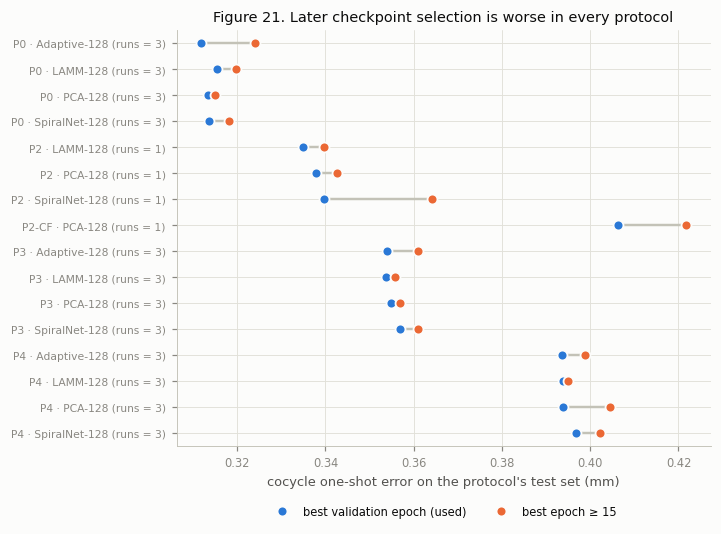

In [33]:
minimum = R.table_csv("stage5", "sensitivity_min_epoch")
minimum["label"] = minimum.protocol + " · " + minimum.representation.map(R.REP_LABEL)
fig, ax = plt.subplots(figsize=(6.6, 4.9))
for y, row in enumerate(minimum.itertuples()):
    ax.plot([row.euclidean_mm_best, row.euclidean_mm_min_epoch_15], [y, y], color=INK["baseline"], linewidth=1.6, zorder=1)
    R.dot(ax, row.euclidean_mm_best, y, SLOTS[0], label="best validation epoch (used)" if y == 0 else None)
    R.dot(ax, row.euclidean_mm_min_epoch_15, y, SLOTS[1], label="best epoch ≥ 15" if y == 0 else None)
ax.set_yticks(range(len(minimum)), [f"{l} (runs = {n})" for l, n in zip(minimum.label, minimum.runs)], fontsize=7)
ax.set_ylim(len(minimum) - 0.5, -0.5)
ax.set_xlabel("cocycle one-shot error on the protocol's test set (mm)")
ax.set_title("Figure 21. Later checkpoint selection is worse in every protocol")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
fig.tight_layout()
plt.show()

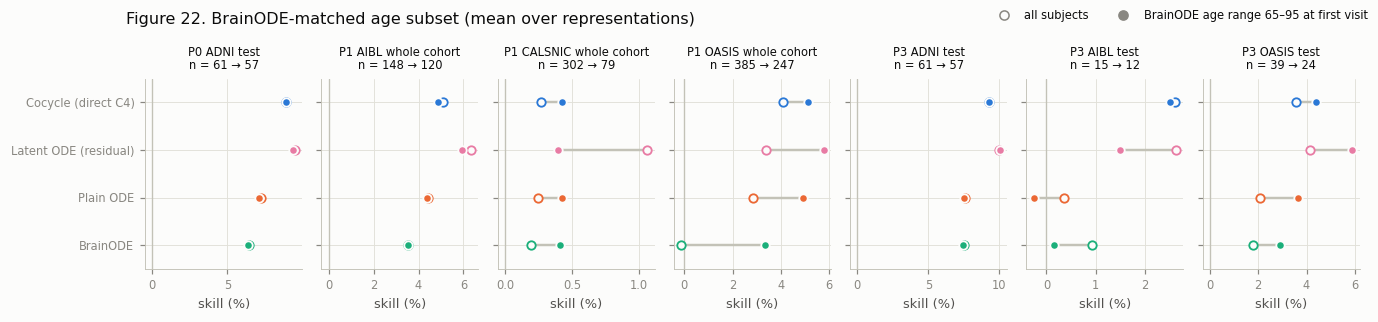

In [34]:
age = R.table_csv("stage5", "sensitivity_age_subset")
part = age[age.method.isin(["direct_c4", "latent_ode_residual", "plain_ode", "brainode"])].groupby(["scope", "method"])[
    ["subjects_all", "subjects_65_95", "skill_all_pct", "skill_65_95_pct"]].mean().reset_index()
scopes = list(dict.fromkeys(part.scope))
fig, axes = plt.subplots(1, len(scopes), figsize=(12.5, 2.9), sharey=True)
for ax, scope in zip(axes, scopes):
    for y, method in enumerate(["direct_c4", "latent_ode_residual", "plain_ode", "brainode"]):
        row = part[(part.scope == scope) & (part.method == method)].iloc[0]
        ax.plot([row.skill_all_pct, row.skill_65_95_pct], [y, y], color=INK["baseline"], linewidth=1.6, zorder=1)
        R.dot(ax, row.skill_all_pct, y, R.METHOD_COLOR[method], filled=False, size=5.5)
        R.dot(ax, row.skill_65_95_pct, y, R.METHOD_COLOR[method], size=5.5)
    ax.axvline(0, color=INK["baseline"], linewidth=0.9)
    ax.set_title(f"{scope}\nn = {int(row.subjects_all)} → {int(row.subjects_65_95)}", fontsize=7.5)
    ax.set_xlabel("skill (%)")
axes[0].set_yticks(range(4), [R.METHOD_LABEL[m] for m in ["direct_c4", "latent_ode_residual", "plain_ode", "brainode"]])
axes[0].set_ylim(3.5, -0.5)
handles = [plt.Line2D([], [], color=INK["muted"], marker="o", markerfacecolor=INK["surface"], linestyle="none"),
           plt.Line2D([], [], color=INK["muted"], marker="o", linestyle="none")]
fig.legend(handles, ["all subjects", "BrainODE age range 65–95 at first visit"], loc="upper right", ncol=2)
fig.suptitle("Figure 22. BrainODE-matched age subset (mean over representations)", x=0.3)
fig.tight_layout()
plt.show()

## 9. Converter line (inclusive AIBL and OASIS-3; descriptive — 5 AD converters in the test split)

The converter cocycle **C1** feeds the cocycle a per-leg average dose c̄(s,t) of a sigmoid condition path
c(τ) = σ((τ − τ_i)/w) with an onset τ_i inside each converter's observed window. Stable subjects keep a constant
condition, so C1 equals the cocycle for them. Test onsets come from a rule: **prefix-only** (the conversion must be
visible in the observed visits) or **oracle window** (all visits, an upper bound). **C0** and **BrainODE-core** use
the source-visit label; **BrainODE-full** re-estimates the condition from the predicted shape at every RK4 substep.

In [35]:
manifest = R.read_json(R.STAGE1 / "views" / R.CONVERTER_VIEW / "view_manifest.json")
rows = []
for split in ("train", "val", "test"):
    counts = manifest["splits"][split]["subjects_by_cohort_group"]
    groups = {}
    for key, value in counts.items():
        groups[key.split("|")[1]] = groups.get(key.split("|")[1], 0) + value
    rows.append({"split": split, **groups})
composition = pd.DataFrame(rows).fillna(0)
display(R.show(composition[["split", "CN-stable", "AD-stable", "CN->AD", "MCI->AD", "CN->MCI"]],
               "Table 12. Converter view subjects per split (ADNI stable subjects included)", precision=0))

split,CN-stable,AD-stable,CN->AD,MCI->AD,CN->MCI
train,674,237,8,20,40
val,85,31,2,3,5
test,85,31,2,3,5


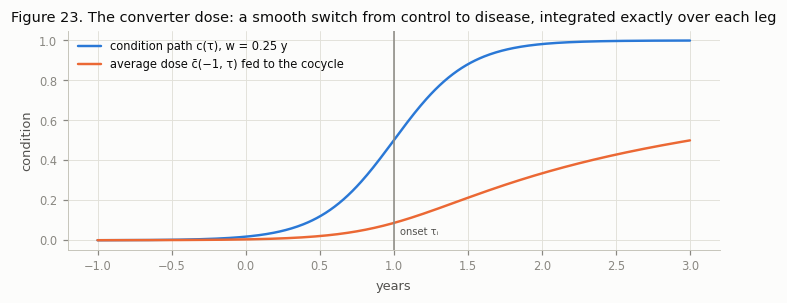

In [36]:
curves = R.dose_curves(onset=1.0, width=0.25)
fig, ax = plt.subplots(figsize=(6.6, 2.8))
ax.plot(curves.years, curves.instantaneous, color=SLOTS[0], label="condition path c(τ), w = 0.25 y")
ax.plot(curves.years, curves.average_from_start, color=SLOTS[1], label="average dose c̄(−1, τ) fed to the cocycle")
ax.axvline(1.0, color=INK["muted"], linewidth=1.0)
ax.annotate("onset τᵢ", (1.0, 0.03), xytext=(4, 0), textcoords="offset points", fontsize=6.5, color=INK["secondary"])
ax.set_xlabel("years")
ax.set_ylabel("condition")
ax.set_title("Figure 23. The converter dose: a smooth switch from control to disease, integrated exactly over each leg")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

In [37]:
converter = R.table_csv("stage5", "r_t3_converter")
columns = ["task", "model", "representation", "stable_mm", "CN-stable_mm", "AD-stable_mm", "CN->AD_mm", "MCI->AD_mm", "AD converters_mm", "AD converters_n", "MCI->AD_capture"]
view = converter[columns].assign(representation=lambda f: f.representation.map(R.REP_LABEL))
view.columns = ["task", "model", "representation", "stable", "CN-stable", "AD-stable", "CN→AD", "MCI→AD", "AD converters", "n converters", "MCI→AD capture"]
display(R.show(view, "Table 13. Converter-line test errors by trajectory group (mm; 3 seeds)", precision=4,
               formats={"n converters": "{:.0f}", "MCI→AD capture": "{:.2f}"}))

task,model,representation,stable,CN-stable,AD-stable,CN→AD,MCI→AD,AD converters,n converters,MCI→AD capture
one_shot_first,BrainODE-core (source label),Adaptive-128,0.3605,0.3654,0.3472,0.7794,0.4452,0.5789,5,0.29
one_shot_first,BrainODE-core (source label),PCA-128,0.3670,0.3696,0.3600,0.7581,0.4487,0.5725,5,0.23
one_shot_first,BrainODE-full (feedback),PCA-128,0.3679,0.3705,0.3609,0.7548,0.4464,0.5697,5,0.25
one_shot_first,C0 (source label),Adaptive-128,0.3547,0.3584,0.3445,0.7691,0.4418,0.5727,5,0.27
one_shot_first,C0 (source label),PCA-128,0.3556,0.3600,0.3436,0.7558,0.4470,0.5705,5,0.18
one_shot_first,C1 c1 (oracle),Adaptive-128,0.3587,0.3640,0.3444,0.7547,0.4083,0.5469,5,0.55
one_shot_first,C1 c1 (oracle),PCA-128,0.3634,0.3705,0.3439,0.7370,0.4205,0.5471,5,0.41
one_shot_first,C1 c1 (prefix),Adaptive-128,0.3587,0.3640,0.3444,0.7672,0.4257,0.5623,5,0.37
one_shot_first,C1 c1 (prefix),PCA-128,0.3634,0.3705,0.3439,0.7498,0.4337,0.5602,5,0.28
one_shot_first,C1 c1_frozen (oracle),Adaptive-128,0.3547,0.3584,0.3445,0.7535,0.4234,0.5554,5,0.45


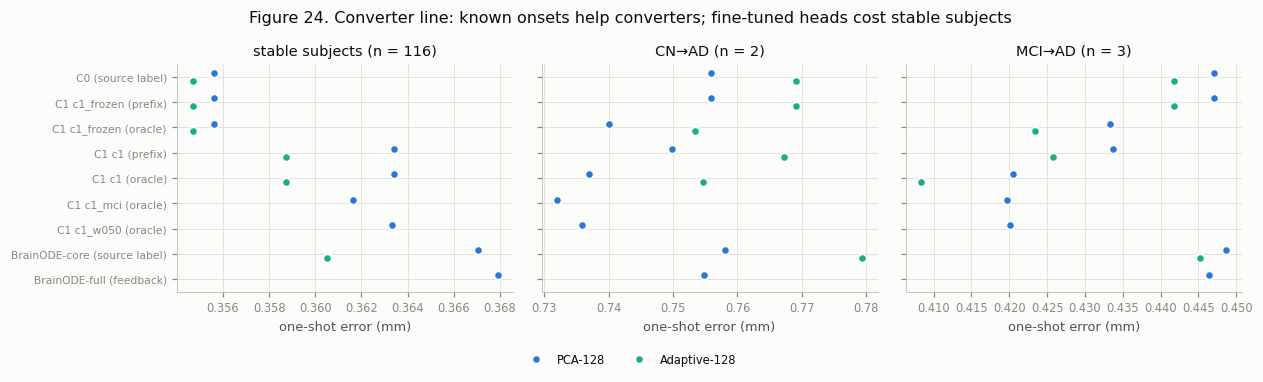

In [38]:
part = converter[converter.task == "one_shot_first"]
models = ["C0 (source label)", "C1 c1_frozen (prefix)", "C1 c1_frozen (oracle)", "C1 c1 (prefix)", "C1 c1 (oracle)", "C1 c1_mci (oracle)",
          "C1 c1_w050 (oracle)", "BrainODE-core (source label)", "BrainODE-full (feedback)"]
groups = [("stable", "stable subjects (n = 116)"), ("CN->AD", "CN→AD (n = 2)"), ("MCI->AD", "MCI→AD (n = 3)")]
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.4), sharey=True)
for ax, (group, title) in zip(axes, groups):
    for representation, color, offset in (("pca128", SLOTS[0], -0.15), ("adaptive128", SLOTS[2], 0.15)):
        cell = part[part.representation == representation].set_index("model")
        for y, model in enumerate(models):
            if model in cell.index:
                R.dot(ax, cell.loc[model, f"{group}_mm"], y + offset, color, label=R.REP_LABEL[representation] if y == 0 else None, size=5.5)
    ax.set_title(title)
    ax.set_xlabel("one-shot error (mm)")
axes[0].set_yticks(range(len(models)), models, fontsize=7)
axes[0].set_ylim(len(models) - 0.5, -0.5)
fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center", ncol=2, bbox_to_anchor=(0.5, 0.0))
fig.suptitle("Figure 24. Converter line: known onsets help converters; fine-tuned heads cost stable subjects")
fig.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

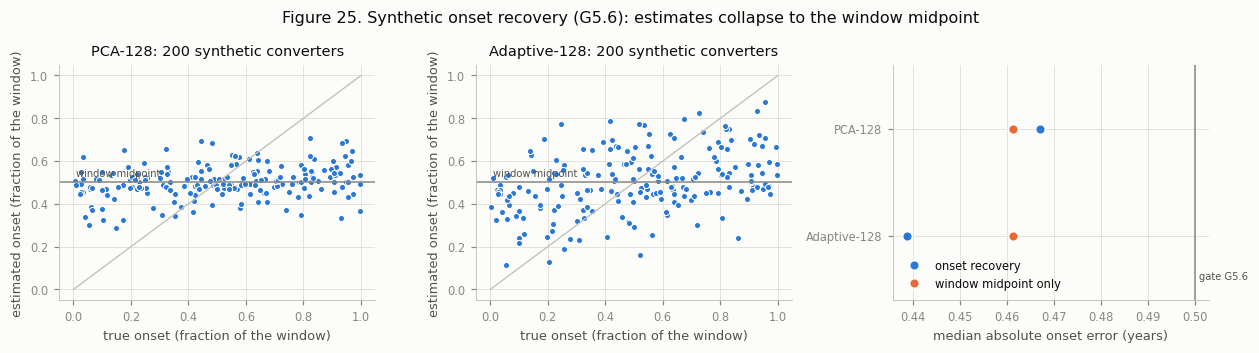

In [39]:
synthetic = R.synthetic_onsets()
main = synthetic[synthetic.width_years == 0.25]
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.2))
for ax, representation in zip(axes[:2], ("pca128", "adaptive128")):
    cell = main[main.representation == representation]
    ax.plot(cell.true_onset_years / cell.window_years, cell.estimate_years / cell.window_years, "o", color=SLOTS[0], markersize=4,
            markeredgecolor=INK["surface"], markeredgewidth=0.7, linestyle="none", label="posterior median")
    ax.plot([0, 1], [0, 1], color=INK["baseline"], linewidth=0.9)
    ax.axhline(0.5, color=INK["muted"], linewidth=1.0)
    ax.annotate("window midpoint", (0.0, 0.5), xytext=(2, 4), textcoords="offset points", fontsize=6.5, color=INK["secondary"])
    ax.set_title(f"{R.REP_LABEL[representation]}: {len(cell)} synthetic converters")
    ax.set_xlabel("true onset (fraction of the window)")
    ax.set_ylabel("estimated onset (fraction of the window)")
summary = main.groupby("representation")[["abs_error_years", "midpoint_abs_error_years"]].median()
for y, representation in enumerate(("pca128", "adaptive128")):
    R.dot(axes[2], summary.loc[representation, "abs_error_years"], y, SLOTS[0], label="onset recovery" if y == 0 else None)
    R.dot(axes[2], summary.loc[representation, "midpoint_abs_error_years"], y, SLOTS[1], label="window midpoint only" if y == 0 else None)
axes[2].axvline(0.5, color=INK["muted"], linewidth=1.0)
axes[2].annotate("gate G5.6", (0.5, 1.4), xytext=(3, 0), textcoords="offset points", fontsize=6.5, color=INK["secondary"])
axes[2].set_yticks([0, 1], [R.REP_LABEL["pca128"], R.REP_LABEL["adaptive128"]])
axes[2].set_ylim(1.6, -0.6)
axes[2].set_xlabel("median absolute onset error (years)")
axes[2].legend(loc="lower left")
fig.suptitle("Figure 25. Synthetic onset recovery (G5.6): estimates collapse to the window midpoint")
fig.tight_layout()
plt.show()

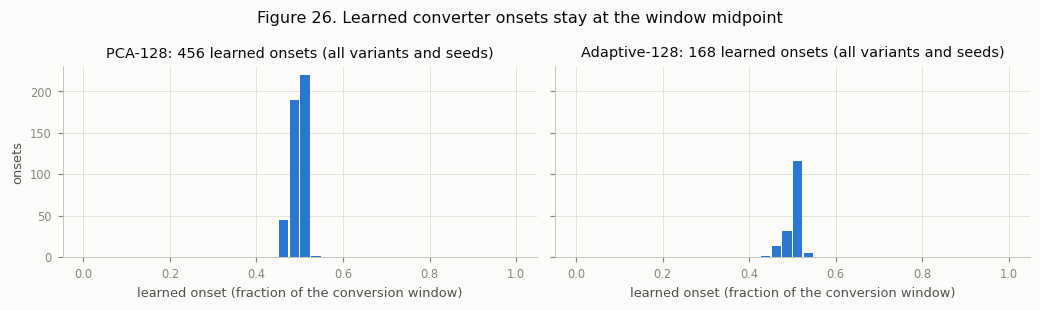

seed,subject AUROC,subject balanced accuracy,scan AUROC,mean c before conversion,mean c after conversion
42,0.958,0.928,0.953,0.313,0.746
43,0.970,0.932,0.965,0.442,0.802
44,0.959,0.912,0.957,0.337,0.748


C1 variant,C0 stable error (mm),C1 stable error (mm),within 1%
C1 c1 (prefix) · adaptive128,0.3547,0.3587,False
C1 c1 (prefix) · pca128,0.3556,0.3634,False
C1 c1_frozen (prefix) · adaptive128,0.3547,0.3547,True
C1 c1_frozen (prefix) · pca128,0.3556,0.3556,True
C1 c1_mci (prefix) · pca128,0.3556,0.3616,False
C1 c1_w050 (prefix) · pca128,0.3556,0.3633,False


In [40]:
onsets = R.learned_onsets()
fig, axes = plt.subplots(1, 2, figsize=(9.5, 2.8), sharey=True)
for ax, representation in zip(axes, ("pca128", "adaptive128")):
    cell = onsets[(onsets.representation == representation) & onsets.variant.isin(["c1", "c1_frozen", "c1_mci", "c1_w050"])]
    ax.hist(cell.onset_fraction_of_window, bins=np.linspace(0, 1, 41), color=SLOTS[0], rwidth=0.85)
    ax.set_title(f"{R.REP_LABEL[representation]}: {len(cell)} learned onsets (all variants and seeds)")
    ax.set_xlabel("learned onset (fraction of the conversion window)")
axes[0].set_ylabel("onsets")
fig.suptitle("Figure 26. Learned converter onsets stay at the window midpoint")
fig.tight_layout()
plt.show()
estimator = R.brainode_full_estimator()
display(R.show(estimator, "Table 14. BrainODE-full cognition estimator on converter-view test subjects (E-C4)", precision=3))
g57 = next(g for g in R.read_json(R.STAGE5 / "reports" / "gates.json")["gates"] if g["id"] == "G5.7")["detail"]
frame = pd.DataFrame([{"C1 variant": key, **value} for key, value in g57.items()])
frame.columns = ["C1 variant", "C0 stable error (mm)", "C1 stable error (mm)", "within 1%"]
display(R.show(frame, "Table 15. Gate G5.7: stable-subject non-inferiority of C1 against C0 (test, one-shot)", precision=4))

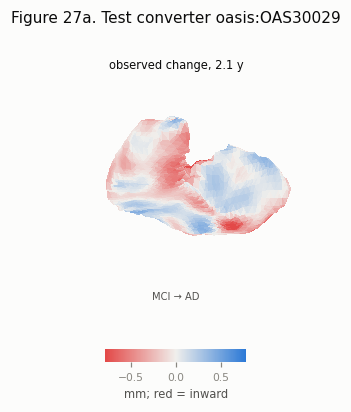

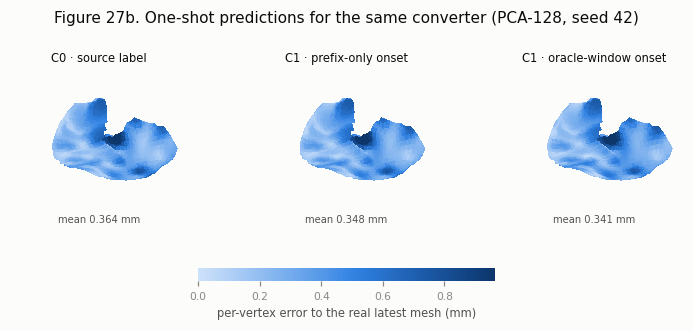

In [41]:
example = R.converter_example()
observed = R.normal_displacement(example["real_first"], example["real_last"])
vmax = float(np.quantile(np.abs(observed), 0.98))
fig = R.render_meshes([{"vertices": example["real_first"], "scalar": observed, "title": f"observed change, {example['years']:.1f} y",
                        "subtitle": " → ".join(example["labels"])}], ncols=1, cmap=R.diverging_cmap(), norm=TwoSlopeNorm(0.0, -vmax, vmax),
                      colorbar_label="mm; red = inward", title=f"Figure 27a. Test converter {example['subject']}", size=(3.2, 2.8))
plt.show()
panels = []
for name, predicted in example["predictions"].items():
    error = np.linalg.norm(predicted - example["real_last"], axis=1)
    panels.append({"vertices": example["real_last"], "scalar": error, "title": name, "subtitle": f"mean {error.mean():.3f} mm"})
vmax = float(np.quantile(np.concatenate([p["scalar"] for p in panels]), 0.99))
fig = R.render_meshes(panels, ncols=3, cmap=R.sequential_cmap(), norm=Normalize(0.0, vmax), colorbar_label="per-vertex error to the real latest mesh (mm)",
                      title="Figure 27b. One-shot predictions for the same converter (PCA-128, seed 42)")
plt.show()

## 10. Context and limitations

In [42]:
context = R.table_csv("stage5", "context_brainode_published")
display(R.show(context, "Table 16. BrainODE's published numbers (NeurIPS 2025) for context — not head-to-head", precision=3))

table,setting,metric,brainode
T7,AIBL,4-shot / 1-shot Euclidean (mm),0.52 ± 0.07 / 0.46 ± 0.05
T7,ADNI,4-shot / 1-shot Euclidean (mm),0.59 ± 0.14 / 0.54 ± 0.15
T7,OASIS,4-shot / 1-shot Euclidean (mm),0.52 ± 0.07 / 0.48 ± 0.08
T8,Exp1 AIBL -> ADNI+OASIS,Euclidean (mm),0.518
T8,Exp2 AIBL+ADNI+OASIS -> LBC1936,Euclidean (mm),0.522
T3,shape accuracy NC&AD / CONV,Euclidean (mm),0.606 / 0.216
T3,cognition estimator,accuracy,0.891


**Limitations.**
- **Absolute errors** are not comparable with BrainODE's: template, mesh fitting, PCA and subject selection differ.
- **Small disease groups outside ADNI.** AIBL has 20 AD subjects, OASIS-3 has 6 and the converter test split has 5
  AD converters; those results are descriptive.
- **CALSNIC** has a short follow-up (median span about 0.7 years) and ALS affects the hippocampus less than AD, so
  every model is close to no-change there.
- **Frozen ADNI representations** reconstruct external cohorts 2.3–2.6× worse than ADNI. The own-cohort basis shows
  this is mostly a property of the external meshes, and the pooled-basis sensitivity arm does not change the ranking.
- **No model predicts individual atrophy rates** (Figure 12). The models reproduce group-level disease effects to
  different degrees.
- **Converter onsets are not identifiable** from shape at the observed noise level (Figures 25–26).

## 11. Reproducibility

Code lives in `examples/LHipp_LatentDynamics_CrossCohort_v1/` (PLAN.md, RUNBOOK.md, scripts, configs, tests);
results live under the bulk root. The consolidated report was produced with
`scripts/report_brainode_style.py --verify` and regenerates byte-identically. This notebook is rebuilt with
`python notebooks/build_results_notebook.py --execute`.

In [43]:
trace = R.table_csv("stage5", "traceability")
print(f"{len(trace)} evaluation summaries feed the consolidated report; {trace.checkpoint_sha256.astype(bool).sum()} carry a checkpoint sha256.")
display(R.show(trace.used_in.str.split(";").explode().value_counts().rename_axis("report section").reset_index(name="summaries"),
               "Table 17. Traceability: evaluation summaries per report section", precision=0))

204 evaluation summaries feed the consolidated report; 204 carry a checkpoint sha256.


report section,summaries
stage3,60
sensitivity_min_epoch,56
r_t3_converter,33
gate_G5.2,27
r_t3_ablations,16
sensitivity_pooled_pca,15
